# 3 · El presupuesto y la Torre en vivo
**Torre del Caribe** · Investigación de Operaciones (criterio 6) y Grandes volúmenes de datos en tiempo casi real (criterio 2)
· Autor: **Brandon Uriel García Sánchez** · UNRC, LCDN 5° semestre 2026-2

| Parte | Pregunta | Técnicas |
|---|---|---|
| A. Presupuesto | ¿Cuánto dinero va a cada lugar, mes y canal? | Programación estocástica de dos etapas (PuLP + CBC), precios sombra, Pareto |
| B. Torre en vivo | ¿Qué hace la campaña esta semana? | Spark Structured Streaming, Isolation Forest, motor de reglas |

| | |
|---|---|
| **Cómo correrlo** | Python 3.11 con `pip install -r requirements.txt` (en la carpeta de la entrega). Para Spark (notebooks 1 y 3), además Java 17: `winget install Microsoft.OpenJDK.17`. Abrir en Jupyter o VS Code y elegir *Ejecutar todo*. |
| **Datos** | Los lee de `datos/` (tablas limpias y resultados). Ya viene ejecutado: se puede leer sin correrlo. |
| **Código** | Va dentro del notebook: cada celda que empieza con `%%modulo` es un archivo del proyecto, completo. |

In [1]:
%matplotlib inline
# Preparación: se corre una vez, al inicio. Encuentra la carpeta de la entrega y define %%modulo, la instrucción que
# convierte una celda de código en un módulo del paquete `torre` (así el notebook no necesita archivos .py).
import os, sys, types, warnings
from pathlib import Path
from IPython.core.magic import register_cell_magic
warnings.filterwarnings("ignore")

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "datos" / "silver").is_dir())
FIGURAS = RAIZ / "2_Notebooks" / "figuras"
FIGURAS.mkdir(parents=True, exist_ok=True)


def _paquete(nombre):
    if nombre not in sys.modules:
        m = types.ModuleType(nombre); m.__path__ = []
        sys.modules[nombre] = m
        if "." in nombre:
            padre, hijo = nombre.rsplit(".", 1)
            setattr(_paquete(padre), hijo, m)
    return sys.modules[nombre]


@register_cell_magic
def modulo(linea, celda):
    """%%modulo torre.radar.indice → ejecuta la celda como el módulo torre.radar.indice."""
    nombre = linea.strip()
    padre, hijo = nombre.rsplit(".", 1)
    m = types.ModuleType(nombre)
    # Ruta simbólica: el código calcula la raíz del proyecto con Path(__file__).parents[3], y aquí da la carpeta de entrega.
    m.__file__ = str(RAIZ / "codigo" / Path(*nombre.split(".")).with_suffix(".py"))
    sys.modules[nombre] = m
    setattr(_paquete(padre), hijo, m)
    try:  # para que Spark pueda mandar a sus trabajadores las funciones definidas aquí
        from pyspark import cloudpickle
        cloudpickle.register_pickle_by_value(m)
    except Exception:
        pass
    exec(compile(celda, m.__file__, "exec"), m.__dict__)


import pandas as pd
pd.set_option("display.max_colwidth", 70)
pd.set_option("display.width", 200)
print("Carpeta de la entrega:", RAIZ)

Carpeta de la entrega: C:\Users\Uriel\Desktop\PP 5to semestre CASCO SANTO TOMAS\Entregable


### Estilo de las gráficas (colores UNRC)
Cada celda de código de abajo es un archivo del paquete `torre`, completo y sin cambios (con su encabezado: qué hace, por qué así, de qué datos sale y a qué decisión alimenta). Al correrla, la celda queda registrada como ese módulo y las celdas siguientes lo usan.

- **`torre.base.entorno`** — Prepara el entorno para que PySpark funcione en Windows y crea la sesión de Spark.
- **`torre.base.silver_huracanes`** — Limpia HURDAT2 (NOAA, todas las tormentas del Atlántico 1851–2025) y la guarda en Silver con una fila por punto de trayectoria (cada 6 horas). A cada punto le calcula su distancia a Chetumal y le pone las banderas que definen "una tormenta que afecta al sur de Quintana Roo".
- **`torre.documento.figuras`** — Dibuja las gráficas del documento ejecutivo con el estilo de la UNRC (guinda #9F2241, dorado #BC955C, tipografía Noto Sans, nunca texto en negro) y las guarda en 2_Notebooks/figuras/.

In [2]:
%%modulo torre.base.entorno
# Autor: Brandon Uriel García Sánchez
# Módulo: Base de datos
# Qué hace:          Prepara el entorno para que PySpark funcione en Windows y crea la sesión de Spark.
# Por qué así:       En esta máquina el Java por defecto es 1.8 (verificado el 26-sep-2026) y PySpark necesita
#                    Java 17. En lugar de cambiar el Java de todo Windows, este módulo apunta JAVA_HOME al JDK 17
#                    solo para el proceso del proyecto. HADOOP_HOME apunta a herramientas/hadoop (winutils.exe y
#                    hadoop.dll 3.3.6), sin los cuales Spark no puede escribir Parquet en Windows.
#                    Alternativa descartada: correr Spark en Docker (funciona, pero es más pesado de explicar y de
#                    arrancar el día del coloquio).
# Datos de entrada:  Ninguno (solo configura el entorno).
# Alimenta a:        Todas las tuberías de Bronze → Silver → Gold (criterio 2 de la rúbrica).

import glob
import os
import sys
from pathlib import Path

# Raíz del proyecto: este archivo vive en backend/torre/base/, así que subimos tres niveles.
RAIZ = Path(__file__).resolve().parents[3]
HADOOP_HOME = RAIZ / "herramientas" / "hadoop"


def buscar_jdk17() -> Path:
    """Busca un JDK 17 instalado en las rutas estándar de Windows.

    Devuelve la carpeta del JDK. Si no hay uno, lanza un error que dice exactamente
    cómo instalarlo; no se sigue con otro Java porque PySpark fallaría más adelante.
    """
    candidatos = []
    for patron in (r"C:\Program Files\Microsoft\jdk-17*",
                   r"C:\Program Files\Eclipse Adoptium\jdk-17*",
                   r"C:\Program Files\Java\jdk-17*"):
        candidatos.extend(glob.glob(patron))
    if not candidatos:
        raise RuntimeError(
            "No encontré un JDK 17. Instálalo con:\n"
            "    winget install Microsoft.OpenJDK.17\n"
            "y vuelve a correr la prueba."
        )
    # Si hay varios, se usa el de versión más alta. Como texto, "jdk-17.0.9" quedaría después de
    # "jdk-17.0.20", así que se ordena por los números de la versión y no alfabéticamente.
    def version(ruta: str) -> tuple:
        numeros = "".join(c if c.isdigit() else " " for c in Path(ruta).name).split()
        return tuple(int(n) for n in numeros)
    return Path(max(candidatos, key=version))


def configurar_entorno() -> dict:
    """Fija JAVA_HOME, HADOOP_HOME y PATH solo para este proceso. Devuelve lo que configuró."""
    jdk = buscar_jdk17()
    os.environ["JAVA_HOME"] = str(jdk)
    os.environ["HADOOP_HOME"] = str(HADOOP_HOME)
    # Se antepone al PATH para que gane sobre el Java 8 del sistema.
    os.environ["PATH"] = os.pathsep.join([str(jdk / "bin"), str(HADOOP_HOME / "bin"), os.environ["PATH"]])
    # Spark arranca "trabajadores" de Python cuando recibe datos creados en Python. En Windows, si no se le dice qué
    # Python usar, se queda esperando y falla con "Accept timed out" (visto el 28-sep-2026 al construir la ocupación
    # de DataTur). Se le indica el mismo Python del proyecto (.venv).
    python = _ruta_corta(sys.executable)
    os.environ["PYSPARK_PYTHON"] = python
    os.environ["PYSPARK_DRIVER_PYTHON"] = python
    return {"JAVA_HOME": str(jdk), "HADOOP_HOME": str(HADOOP_HOME), "PYSPARK_PYTHON": python}


def _ruta_corta(ruta: str) -> str:
    """Devuelve la ruta "corta" de Windows, sin espacios (por ejemplo, la carpeta "PP 5to semestre..." pasa a "PP5TOS~1").

    La carpeta del proyecto tiene espacios ("PP 5to semestre ...") y los scripts de Spark la cortan en "5to"
    ("'5to' is not recognized", visto el 28-sep-2026). La ruta corta evita el problema. Fuera de Windows no cambia nada.
    """
    if os.name != "nt":
        return ruta
    import ctypes

    buffer = ctypes.create_unicode_buffer(1024)
    n = ctypes.windll.kernel32.GetShortPathNameW(ruta, buffer, len(buffer))
    return buffer.value if 0 < n < len(buffer) else ruta


def crear_spark(nombre_app: str = "torre-del-caribe"):
    """Crea una sesión de Spark local que usa todos los núcleos de la máquina.

    local[*]    = modo local con todos los núcleos (12 en esta máquina).
    driver 4g   = memoria para el proceso principal (la máquina tiene 16 GB).
    timeZone    = UTC, para que las fechas no se muevan entre máquinas.
    progreso    = apagado, para que los resúmenes se lean limpios.
    """
    configurar_entorno()
    from pyspark.sql import SparkSession  # se importa después de fijar JAVA_HOME

    return (
        SparkSession.builder.appName(nombre_app)
        .master("local[*]")
        .config("spark.driver.memory", "4g")
        .config("spark.sql.session.timeZone", "UTC")
        # Sin barra de progreso en la terminal: tapaba los resúmenes impresos por los procesos.
        .config("spark.ui.showConsoleProgress", "false")
        .getOrCreate()
    )


In [3]:
%%modulo torre.base.silver_huracanes
# Autor: Brandon Uriel García Sánchez
# Módulo: Base de datos
# Qué hace:          Limpia HURDAT2 (NOAA, todas las tormentas del Atlántico 1851–2025) y la guarda en Silver con una fila
#                    por punto de trayectoria (cada 6 horas). A cada punto le calcula su distancia a Chetumal y le pone
#                    las banderas que definen "una tormenta que afecta al sur de Quintana Roo".
# Por qué así:       - Definición elegida por el equipo (30-sep-2026, docs/decisiones/10-silver-fase5.md): un evento es una
#                      tormenta con al menos un punto a ≤ 200 km de Chetumal y viento ≥ 34 nudos (tormenta tropical o
#                      huracán), contada desde 1966 (inicio de la vigilancia por satélite): 31 eventos en 60 años.
#                      Alternativas descartadas: 100 km (13 eventos desde 1966: muy pocos para una tasa por mes),
#                      300 km (59 eventos: incluye tormentas que pasan por el norte de Yucatán y por Honduras) y contar
#                      desde 1851 (0.469 por año contra 0.517: antes de los satélites se perdían tormentas en el mar).
#                    - Se guardan TODOS los puntos (no solo los del sur) para que el radio o el umbral se puedan
#                      cambiar sin volver a leer el texto crudo (análisis de sensibilidad en la Fase 5).
#                    - Parser con expresión regular sobre la posición, el viento y la presión: 2 de 55,524 líneas
#                      vienen mal formadas en el archivo oficial. 1969-09-29 06Z trae "63.3N    7.5E" sin coma (se lee
#                      completa) y 1975-12-07 00Z trae "38.83" sin hemisferio (la latitud queda nula; no se adivina).
#                      Ambas se marcan con formato_irregular_flag. Las dos están en el Atlántico norte, a más de
#                      3,000 km de Chetumal: no cambian el conteo.
#                    - Faltantes oficiales de HURDAT2: viento -99 y presión -999 se guardan como nulos, no como números.
#                    - Texto → pandas (el formato alterna encabezados y filas) y Spark escribe el Parquet por año.
# Datos de entrada:  datos/bronze/huracanes/<fecha>/hurdat2-1851-2025-*.txt (D9).
# Alimenta a:        A3 Pronóstico: probabilidad mensual de tormenta (Poisson) y choques del Monte Carlo, que deciden en
#                    qué meses la campaña reserva presupuesto de contingencia.

import math
import re

import pandas as pd

from torre.base.entorno import RAIZ, crear_spark

BRONZE = RAIZ / "datos" / "bronze"
SILVER_HURACANES = RAIZ / "datos" / "silver" / "huracanes"

CHETUMAL = (18.50, -88.30)     # centro del sur de Quintana Roo (bahía de Chetumal)
RADIO_KM = 200                 # decisión del equipo, 30-sep-2026
VIENTO_MIN_KT = 34             # 34 nudos ≈ 63 km/h: umbral oficial de tormenta tropical
ANIO_SATELITAL = 1966          # primer año con vigilancia por satélite continua

# Posición + viento + presión. Tolera "18.5N, 88.3W" (normal) y "63.3N    7.5E" (sin coma entre las dos).
POS = re.compile(r"(\d+\.\d)([NS])[\s,]*(\d+\.\d)([EW])\s*,\s*(-?\d+)\s*,\s*(-?\d+)")
# Latitud sin hemisferio ("38.83,  51.0W", tormenta de 1975): la latitud no se adivina, queda nula.
POS_SIN_HEMISFERIO = re.compile(r"(\d+\.\d+)\s*,\s*(\d+\.\d)([EW])\s*,\s*(-?\d+)\s*,\s*(-?\d+)")
LAT_BIEN = re.compile(r"\d+\.\d[NS]")


def km_haversine(lat1, lon1, lat2, lon2) -> float:
    """Distancia sobre la esfera terrestre (radio 6,371 km). Ecuación en ECUACIONES.md §3.1."""
    p = math.pi / 180
    a = (math.sin((lat2 - lat1) * p / 2) ** 2
         + math.cos(lat1 * p) * math.cos(lat2 * p) * math.sin((lon2 - lon1) * p / 2) ** 2)
    return 2 * 6371 * math.asin(math.sqrt(a))


def leer_hurdat2() -> pd.DataFrame:
    """Recorre el archivo: una línea de encabezado (id, nombre, n puntos) seguida de n líneas de trayectoria."""
    archivo = sorted(BRONZE.glob("huracanes/*/hurdat2-1851-*.txt"))[-1]
    lineas = archivo.read_text(encoding="utf-8").splitlines()
    filas, i = [], 0
    while i < len(lineas):
        cab = [x.strip() for x in lineas[i].split(",")]
        id_tormenta, nombre, n = cab[0], cab[1], int(cab[2])
        for linea in lineas[i + 1:i + 1 + n]:
            c = [x.strip() for x in linea.split(",")]
            m = POS.search(linea)
            if m:
                lat = float(m.group(1)) * (1 if m.group(2) == "N" else -1)
                lon_txt, hemi_lon, viento, presion = m.group(3), m.group(4), int(m.group(5)), int(m.group(6))
            else:
                m = POS_SIN_HEMISFERIO.search(linea)
                if not m:  # regla de oro 5: una línea que no se entiende detiene el proceso
                    raise ValueError(f"HURDAT2: línea sin posición legible en {id_tormenta}: {linea[:60]}")
                lat = None
                lon_txt, hemi_lon, viento, presion = m.group(2), m.group(3), int(m.group(4)), int(m.group(5))
            filas.append({
                "id_tormenta": id_tormenta, "nombre": nombre,
                "fecha": c[0], "hora_utc": c[1], "marca": c[2] or None, "estado_sistema": c[3],
                "lat": lat, "lon": float(lon_txt) * (-1 if hemi_lon == "W" else 1),
                "viento_kt": None if viento == -99 else viento,
                "presion_mb": None if presion == -999 else presion,
                "formato_irregular_flag": not LAT_BIEN.fullmatch(c[4]),
            })
        i += 1 + n
    d = pd.DataFrame(filas)
    d["anio"] = d.fecha.str[:4].astype(int)
    d["mes"] = d.fecha.str[4:6].astype(int)
    d["fecha_hora_utc"] = pd.to_datetime(d.fecha + d.hora_utc.str.zfill(4), format="%Y%m%d%H%M")
    # Spark en Windows no convierte marcas de tiempo anteriores a 1970 (mktime): se guarda fecha + hora en número.
    d["fecha"] = d.fecha_hora_utc.dt.date
    d["hora_utc"] = d.hora_utc.astype(int)
    d["archivo"] = str(archivo.relative_to(RAIZ))
    return d


def agregar_banderas(d: pd.DataFrame) -> pd.DataFrame:
    d["km_chetumal"] = [None if pd.isna(a) else round(km_haversine(a, b, *CHETUMAL), 1) for a, b in zip(d.lat, d.lon)]
    d["dentro_radio_flag"] = d.km_chetumal.fillna(float("inf")) <= RADIO_KM  # sin latitud no se puede afirmar cercanía
    d["tormenta_o_huracan_flag"] = d.viento_kt.fillna(0) >= VIENTO_MIN_KT
    d["era_satelital_flag"] = d.anio >= ANIO_SATELITAL
    d["afecta_sur_flag"] = d.dentro_radio_flag & d.tormenta_o_huracan_flag & d.era_satelital_flag
    return d


def eventos_sur(d: pd.DataFrame) -> pd.DataFrame:
    """Una fila por tormenta que afecta al sur: mes del primer punto que cumple la definición, viento máximo dentro
    del radio y distancia mínima a Chetumal. Es la serie que usa el modelo de Poisson de la Fase 5."""
    x = d[d.afecta_sur_flag].sort_values(["fecha", "hora_utc"])
    return (x.groupby("id_tormenta")
             .agg(nombre=("nombre", "first"), anio=("anio", "first"), mes=("mes", "first"),
                  viento_max_kt=("viento_kt", "max"), km_min=("km_chetumal", "min"))
             .reset_index().sort_values(["anio", "mes"]).reset_index(drop=True))


def construir_silver_huracanes(spark=None):
    spark = spark or crear_spark("silver-huracanes")
    d = agregar_banderas(leer_hurdat2())
    columnas = ["id_tormenta", "nombre", "anio", "mes", "fecha", "hora_utc", "marca", "estado_sistema", "lat", "lon",
                "viento_kt", "presion_mb", "km_chetumal", "dentro_radio_flag", "tormenta_o_huracan_flag",
                "era_satelital_flag", "afecta_sur_flag", "formato_irregular_flag", "archivo"]
    d = d[columnas]
    df = spark.createDataFrame(d.astype({"viento_kt": "Int64", "presion_mb": "Int64", "marca": "object"}))
    df.write.mode("overwrite").partitionBy("anio").parquet(str(SILVER_HURACANES))
    ev = eventos_sur(d)
    anios = d.anio.max() - ANIO_SATELITAL + 1
    print(f"HURDAT2 Silver: {len(d):,} puntos de {d.id_tormenta.nunique():,} tormentas ({d.anio.min()}–{d.anio.max()}); "
          f"{int(d.formato_irregular_flag.sum())} líneas con formato irregular")
    print(f"Afectan al sur (≤{RADIO_KM} km de Chetumal, ≥{VIENTO_MIN_KT} kt, desde {ANIO_SATELITAL}): "
          f"{len(ev)} eventos en {anios} años = {len(ev) / anios:.3f} por año")
    print("Eventos por mes:", ev.mes.value_counts().sort_index().to_dict())
    return d


In [4]:
%%modulo torre.documento.figuras
# Autor: Brandon Uriel García Sánchez
# Módulo: Documento ejecutivo
# Qué hace:          Dibuja las gráficas del documento ejecutivo con el estilo de la UNRC (guinda #9F2241,
#                    dorado #BC955C, tipografía Noto Sans, nunca texto en negro) y las guarda en
#                    docs/ejecutivo/figuras/.
# Por qué así:       Los colores y la tipografía salen de la Guía de Identidad Gráfica UNRC 2024-2030 (págs. 9,
#                    17-19 y 26), resumida en docs/ejecutivo/GUIA_ESTILO_UNRC.md. Noto Sans vive en
#                    herramientas/fuentes/ para no tener que instalarla en Windows.
#                    Cada función lee un archivo oficial de datos/bronze/: la gráfica muestra exactamente lo que
#                    publicó la fuente.
# Datos de entrada:  DataTur BdINAH (D4) y SITUR-Q (D1) en datos/bronze/.
# Alimenta a:        Capítulos del documento ejecutivo (selección de regiones, Fase 1).

import json
import sys
from pathlib import Path

import matplotlib

# Fuera de un notebook se dibuja a archivo, sin abrir ventanas. Dentro de un notebook NO se fuerza "Agg": si no, las
# gráficas no quedan dentro del notebook (el 30-sep-2026 los notebooks 01 y 02 salían sin ninguna imagen).
if "ipykernel" not in sys.modules:
    matplotlib.use("Agg")
import matplotlib.pyplot as plt
from matplotlib import font_manager

RAIZ = Path(__file__).resolve().parents[3]
FIGURAS = RAIZ / "2_Notebooks" / "figuras"
BRONZE = RAIZ / "datos" / "bronze"

GUINDA, DORADO, GRIS_TEXTO, GRIS_SUAVE = "#9F2241", "#BC955C", "#3A3A3A", "#BDBDBD"
PALETA = ["#9F2241", "#BC955C", "#565393", "#58A65D", "#8CAFDD", "#F26E50", "#465973"]


def estilo_unrc():
    """Aplica el estilo UNRC a todas las gráficas: Noto Sans, textos en gris oscuro, sin marco pesado."""
    for f in (RAIZ / "herramientas" / "fuentes").glob("NotoSans-*.ttf"):
        font_manager.fontManager.addfont(str(f))
    plt.rcParams.update({
        "font.family": "Noto Sans", "font.size": 10,
        "text.color": GRIS_TEXTO, "axes.labelcolor": GRIS_TEXTO,
        "xtick.color": GRIS_TEXTO, "ytick.color": GRIS_TEXTO,
        "axes.edgecolor": GRIS_SUAVE, "axes.spines.top": False, "axes.spines.right": False,
        "axes.titleweight": "bold", "axes.titlecolor": GUINDA, "axes.titlesize": 13,
        "figure.facecolor": "white", "savefig.dpi": 200, "savefig.bbox": "tight",
    })


def _ultimo(patron: str) -> Path:
    """Devuelve el archivo más reciente de Bronze que coincide con el patrón (la última descarga)."""
    rutas = sorted(BRONZE.glob(patron))
    if not rutas:
        raise FileNotFoundError(f"No hay archivo en Bronze para {patron}; primero corre la ingesta (Fase 1).")
    return rutas[-1]


def _pie(ax, texto: str):
    """Línea de fuente al pie de la gráfica, obligatoria en el documento ejecutivo."""
    ax.figure.text(0.01, -0.02, texto, fontsize=8, color=GRIS_TEXTO, ha="left", va="top")


def visitantes_inah_2025() -> Path:
    """Barras: visitantes 2025 por zona arqueológica de Q. Roo (INAH). Guinda = regiones que se promueven."""
    import pandas as pd

    zipf = _ultimo("datatur/*/inah/BdINAH.zip")
    df = pd.read_excel(zipf, sheet_name=0) if zipf.suffix == ".xlsx" else _leer_inah(zipf)
    q = df[(df["Estado"] == "Quintana Roo") & (df["Año"] == 2025) & df["Nombre"].str.startswith("Z.A")]
    tot = q.groupby("Nombre")["Visitantes"].sum().sort_values()
    tot = tot[tot > 0]
    promovidas = ("Kohunlich", "Dzibanch", "Ichkabal", "Oxtankah")  # zonas de las 5 regiones (28-sep-2026)
    colores = [GUINDA if any(p in n for p in promovidas) else DORADO for n in tot.index]

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(8, 4.6))
    etiquetas = [n.replace("Z.A. de ", "").replace("Z.A de ", "") for n in tot.index]
    ax.barh(etiquetas, tot.values, color=colores)
    for i, v in enumerate(tot.values):
        ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8, color=GRIS_TEXTO)
    ax.set_title("Tulum recibe más de 1 millón de visitantes; la ruta del sur, menos de 70 mil")
    ax.set_xlabel("Visitantes en 2025 (nacionales + extranjeros)")
    ax.xaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f} M" if x >= 1e6 else f"{x/1e3:.0f} mil"))
    ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=GUINDA), plt.Rectangle((0, 0), 1, 1, color=DORADO)],
              labels=["Región que promueve la campaña", "Fuera del foco (referencia, crucero o retirada)"], frameon=False, loc="lower right")
    _pie(ax, f"Fuente: SECTUR-DataTur, base de visitantes del INAH (archivo {zipf.name}, descargado el {zipf.parts[-3]}).")
    salida = FIGURAS / "f01_visitantes_inah_2025.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def _leer_inah(zipf: Path):
    """Lee el Excel que viene dentro de BdINAH.zip."""
    import io
    import zipfile

    import pandas as pd

    with zipfile.ZipFile(zipf) as z:
        nombre = next(n for n in z.namelist() if n.lower().endswith(".xlsx"))
        return pd.read_excel(io.BytesIO(z.read(nombre)))


def cobertura_ocupacion_siturq() -> Path:
    """Mapa de calor: cuántos meses con dato de ocupación hotelera tiene cada destino en cada año (SITUR-Q)."""
    import numpy as np

    archivo = _ultimo("siturq/*/ocupacion_hotelera.json")
    bloque = json.loads(archivo.read_text(encoding="utf-8"))
    unidades = list(dict.fromkeys(r["unidad"] for r in bloque))
    anios = sorted({r["anio"] for r in bloque})
    matriz = np.zeros((len(unidades), len(anios)))
    for r in bloque:
        filas = (r.get("respuesta") or {}).get("data") or []
        con_dato = [f for f in filas if float(f.get("Ocupación hotelera") or 0) > 0]
        matriz[unidades.index(r["unidad"]), anios.index(r["anio"])] = len(con_dato)

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(8, 5.2))
    mapa = matplotlib.colors.LinearSegmentedColormap.from_list("unrc", ["#F4ECEE", GUINDA])
    ax.imshow(matriz, cmap=mapa, vmin=0, vmax=12, aspect="auto")
    ax.set_xticks(range(len(anios)), anios)
    ax.set_yticks(range(len(unidades)), unidades)
    for i in range(len(unidades)):
        for j in range(len(anios)):
            v = int(matriz[i, j])
            ax.text(j, i, v if v else "–", ha="center", va="center", fontsize=8,
                    color="white" if v > 6 else GRIS_TEXTO)
    ax.set_title("La ocupación hotelera oficial de SITUR-Q termina en diciembre de 2024")
    ax.set_xlabel("Año (número = meses con dato publicado)")
    for s in ax.spines.values():
        s.set_visible(False)
    _pie(ax, f"Fuente: SITUR-Q, indicador «Ocupación hotelera», consulta del {archivo.parts[-2]} (archivo {archivo.name}).")
    salida = FIGURAS / "f02_cobertura_ocupacion_siturq.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def volumen_bronze() -> Path:
    """Barras: cuántos registros aportó cada fuente oficial a Bronze (escala logarítmica, del manifiesto)."""
    import pandas as pd

    m = pd.read_csv(BRONZE / "MANIFIESTO.csv")
    m = m[m.fuente != "Evidencia sargazo"]  # capturas de noticias: evidencia, no datos
    m["filas"] = pd.to_numeric(m["filas"], errors="coerce").fillna(0)
    r = m.groupby("fuente")["filas"].sum()
    r = r[r > 0].sort_values()
    etiquetas = [f.split(" ", 1)[1] for f in r.index]  # quita el código D1, D2...

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(8, 5))
    colores = [GUINDA if v >= 100_000 else DORADO for v in r.values]
    ax.barh(etiquetas, r.values, color=colores)
    ax.set_xscale("log")
    for i, v in enumerate(r.values):
        ax.text(v, i, f" {v:,.0f}", va="center", fontsize=8, color=GRIS_TEXTO)
    ax.set_title(f"{m['filas'].sum():,.0f} registros oficiales reunidos de {len(r)} fuentes")
    ax.set_xlabel("Registros por fuente (escala logarítmica: cada marca multiplica por 10)")
    _pie(ax, f"Fuente: manifiesto de datos crudos del proyecto (datos/bronze/MANIFIESTO.csv), {len(m)} archivos, "
             f"{m['bytes'].sum() / 1e6:,.0f} MB.")
    salida = FIGURAS / "f03_volumen_bronze.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def costos_publicitarios_travel() -> Path:
    """Barras: costo por clic (USD) y tasa de clics (%) de la categoría Travel por canal y editor (D13)."""
    import pandas as pd

    archivo = _ultimo("benchmarks/*/benchmarks_tablas.csv")
    d = pd.read_csv(archivo)
    t = d[(d.categoria == "Travel") & d.metrica.isin(["Average CPC", "Average CTR"])].copy()
    # Etiqueta en tres líneas (editor / canal / año) para que no se encimen en el eje
    canal = t["canal"].str.replace(" (Google/Microsoft)", "", regex=False).str.replace(" Ads", "", regex=False)
    t["serie"] = t["editor"] + "\n" + canal + "\n" + t["anio"].astype(str)
    cpc = t[t.metrica == "Average CPC"].set_index("serie")["valor"]
    ctr = t[t.metrica == "Average CTR"].set_index("serie")["valor"].reindex(cpc.index)

    estilo_unrc()
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 4.2))
    a1.bar(cpc.index, cpc.values, color=[GUINDA if "Facebook" not in s else DORADO for s in cpc.index])
    a1.set_title("Costo por clic (USD)", fontsize=11)
    a2.bar(ctr.index, ctr.values, color=[GUINDA if "Facebook" not in s else DORADO for s in ctr.index])
    a2.set_title("Personas que dan clic de cada 100 (CTR, %)", fontsize=11)
    for ax, serie, fmt in ((a1, cpc, "${:.2f}"), (a2, ctr, "{:.2f} %")):
        ax.tick_params(axis="x", labelsize=7)
        for i, v in enumerate(serie.values):
            ax.text(i, v, fmt.format(v), ha="center", va="bottom", fontsize=8, color=GRIS_TEXTO)
    fig.suptitle("Un clic en Facebook cuesta 4 a 5 veces menos que en buscadores (turismo)",
                 color=GUINDA, fontweight="bold", fontsize=13)
    _pie(a1, f"Fuente: WordStream 2025 y LocaliQ 2026, categoría «Travel» (promedios de anunciantes de EE. UU.), "
             f"extraído el {archivo.parts[-2]}.")
    salida = FIGURAS / "f04_costos_publicitarios_travel.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def ocupacion_semanal_qroo() -> Path:
    """Líneas: ocupación hotelera semanal 2022–2026 de los centros de Q. Roo (DataTur, ya limpia en Silver).

    Se muestra el promedio móvil de 4 semanas para que se lea la tendencia y no el ruido semana a semana.
    """
    import pandas as pd

    d = pd.read_parquet(RAIZ / "datos" / "silver" / "datatur_ocupacion")
    s = d[(d.frecuencia == "semanal") & d.es_qroo & (d.tipo_fila == "centro")].copy()
    s["periodo"] = pd.to_datetime(s["periodo"])
    series = {"Cancun": ("Cancún", GUINDA), "Riviera Maya": ("Riviera Maya", DORADO),
              "Cozumel": ("Cozumel", PALETA[2]), "Isla Mujeres": ("Isla Mujeres", PALETA[3])}

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(9, 4.4))
    for centro, (etiqueta, color) in series.items():
        c = s[s.centro == centro].sort_values("periodo").set_index("periodo")["ocupacion_pct"]
        ax.plot(c.rolling(4, min_periods=1).mean(), color=color, lw=1.8, label=etiqueta)
    ax.axvline(pd.Timestamp("2025-09-01"), color=GRIS_SUAVE, ls="--", lw=1)
    ax.text(pd.Timestamp("2025-09-08"), 97, "Sep-2025: DataTur actualiza\nla oferta de Isla Mujeres", fontsize=7.5,
            color=GRIS_TEXTO, va="top")
    ax.set_ylim(10, 100)
    ax.set_ylabel("Ocupación hotelera (%)")
    ax.set_title("Cancún y Riviera Maya rondan el 74 %; Cozumel e Isla Mujeres, el 52 %")
    ax.legend(frameon=False, ncol=4, loc="upper center", bbox_to_anchor=(0.5, -0.12))
    _pie(ax, "Fuente: SECTUR-DataTur, monitoreo semanal de ocupación hotelera 2022–2026 (promedio móvil de 4 semanas), "
             "datos limpios del proyecto.")
    fig.subplots_adjust(bottom=0.2)
    salida = FIGURAS / "f05_ocupacion_semanal_qroo.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def oferta_turistica_municipios() -> Path:
    """Barras apiladas: negocios turísticos por municipio de Q. Roo y por giro (DENUE, ya limpio en Silver)."""
    import pandas as pd

    d = pd.read_parquet(RAIZ / "datos" / "silver" / "denue", columns=["cve_ent", "municipio", "categoria_turistica", "es_turistico"])
    q = d[(d.cve_ent.astype(str) == "23") & d.es_turistico]
    tabla = q.pivot_table(index="municipio", columns="categoria_turistica", aggfunc="size", fill_value=0)
    tabla = tabla.loc[tabla.sum(axis=1).sort_values().index]
    orden = ["Alimentos y bebidas", "Alojamiento", "Esparcimiento", "Agencias de viajes", "Museos y sitios históricos", "Transporte turístico"]
    tabla = tabla[[c for c in orden if c in tabla.columns]]

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(9, 4.8))
    izquierda = None
    for i, col in enumerate(tabla.columns):
        ax.barh(tabla.index, tabla[col], left=izquierda, color=PALETA[i % len(PALETA)], label=col)
        izquierda = tabla[col] if izquierda is None else izquierda + tabla[col]
    for i, total in enumerate(tabla.sum(axis=1)):
        ax.text(total, i, f" {total:,}", va="center", fontsize=8, color=GRIS_TEXTO)
    ax.set_xlabel("Negocios turísticos registrados")
    ax.set_title(f"{len(q):,} negocios turísticos en Quintana Roo; 4 de cada 10 están en Benito Juárez (Cancún)")
    ax.legend(frameon=False, fontsize=8, ncol=3, loc="upper center", bbox_to_anchor=(0.45, -0.14))
    _pie(ax, "Fuente: INEGI, Directorio Estadístico Nacional de Unidades Económicas (DENUE), giros característicos del "
             "turismo (SCIAN 721, 722, 5615, 487, 712, 713); datos limpios del proyecto.")
    fig.subplots_adjust(bottom=0.25)
    salida = FIGURAS / "f06_oferta_turistica_municipios.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def lluvia_y_huracanes() -> Path:
    """Barras: lluvia media de cada mes en Chetumal (1991–2020) y, encima, cuántas tormentas afectaron al sur en ese mes
    (1966–2025). Muestra en una sola imagen que la temporada de lluvias y la de huracanes caen en los mismos meses."""
    import pandas as pd

    from torre.base.silver_huracanes import eventos_sur

    dia = pd.read_parquet(RAIZ / "datos" / "silver" / "clima_diario")
    c = dia[(dia.punto == "chetumal") & dia.anio.astype(int).between(1991, 2020)]
    lluvia = c.groupby(["anio", "mes"], observed=True).lluvia_mm.sum().groupby("mes").mean()
    ev = eventos_sur(pd.read_parquet(RAIZ / "datos" / "silver" / "huracanes")).mes.value_counts()
    meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(9, 4.4))
    colores = [GUINDA if ev.get(m, 0) > 0 else GRIS_SUAVE for m in range(1, 13)]
    ax.bar(meses, [lluvia[m] for m in range(1, 13)], color=colores)
    for i, m in enumerate(range(1, 13)):
        n = ev.get(m, 0)
        ax.text(i, lluvia[m] + 4, f"{lluvia[m]:.0f} mm", ha="center", fontsize=8)
        if n:  # el número de tormentas va dentro de la barra para que no se encime con la lluvia
            ax.text(i, lluvia[m] - 8, str(n), ha="center", va="top", fontsize=13, color="white", fontweight="bold")
    ax.set_ylim(0, 215)
    ax.set_ylabel("Lluvia media del mes (mm)")
    ax.set_title("En Chetumal, las lluvias y las tormentas llegan juntas: de mayo a noviembre")
    _pie(ax, "Fuente: Open-Meteo (reanálisis ERA5), lluvia diaria en Chetumal 1991–2020; NOAA HURDAT2, tormentas a "
             "200 km o menos de Chetumal\ncon viento de 34 nudos o más, 1966–2025 (31 en total). El número blanco "
             "dentro de cada barra guinda = tormentas de ese mes. Datos limpios del proyecto.")
    salida = FIGURAS / "f09_lluvia_y_huracanes.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def forma_del_anio() -> Path:
    """Líneas: índice estacional por mes de cada serie del Pronóstico (1 = mes promedio). Sale de la pieza 2 de la Fase 5
    (torre.pronostico.forma), con años completos solamente."""
    import pandas as pd

    forma = pd.read_parquet(RAIZ / "datos" / "gold" / "pronostico_forma_anio.parquet")
    meses = ["Ene", "Feb", "Mar", "Abr", "May", "Jun", "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"]
    estilos = {"Ruta arqueológica del sur": (GUINDA, "-", "Ruta arqueológica del sur (visitantes INAH)"),
               "Bahía Calderitas–Oxtankah": (DORADO, "-", "Bahía Calderitas–Oxtankah (visitantes INAH)"),
               "Chetumal": (PALETA[2], "-", "Chetumal (cruces desde Belice)"),
               "Cancún": (GRIS_TEXTO, "--", "Cancún, referencia (ocupación hotelera)")}

    estilo_unrc()
    fig, ax = plt.subplots(figsize=(9, 4.4))
    for lugar, (color, linea, etiqueta) in estilos.items():
        f = forma[forma.lugar == lugar].sort_values("mes")
        ax.plot(meses, f.indice, color=color, ls=linea, lw=2.2 if linea == "-" else 1.6, marker="o", ms=4, label=etiqueta)
    ax.axhline(1, color=GRIS_SUAVE, lw=1)
    ax.set_ylabel("Índice del mes (1 = promedio del año)")
    ax.set_title("Las zonas del sur se llenan en diciembre y enero y se vacían en septiembre")
    ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.1), fontsize=8.5)
    _pie(ax, "Fuente: INAH (BdINAH), SITUR-Q (frontera México–Belice) y SECTUR-DataTur; solo años completos sin cierres ni "
             "pandemia\n(zonas: 2016–2019, 2022 y 2023 o 2025; Belice: 2019 y 2023–2025; Cancún: 2022–2025). "
             "Cálculo del proyecto.")
    fig.subplots_adjust(bottom=0.24)
    salida = FIGURAS / "f10_forma_del_anio.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def pronostico_12_meses() -> Path:
    """Tres paneles (lugares del sur): últimos 24 meses reales y pronóstico de 12 meses con su rango del 90 % (pieza 3 de
    la Fase 5, modelo elegido con el criterio del equipo)."""
    import pandas as pd

    t = pd.read_parquet(RAIZ / "datos" / "gold" / "pronostico_series.parquet")
    f = pd.read_parquet(RAIZ / "datos" / "gold" / "pronostico_mes.parquet")
    paneles = [("Ruta arqueológica del sur", "Ruta arqueológica del sur\n(visitantes INAH al mes)"),
               ("Bahía Calderitas–Oxtankah", "Bahía Calderitas–Oxtankah\n(visitantes INAH al mes)"),
               ("Chetumal", "Chetumal\n(cruces desde Belice al mes)")]

    estilo_unrc()
    fig, ejes = plt.subplots(1, 3, figsize=(11, 3.9))
    for ax, (lugar, titulo) in zip(ejes, paneles):
        s = t[t.lugar == lugar].sort_values("periodo").tail(24)
        p = f[f.lugar == lugar].sort_values("periodo")
        ax.plot(s.periodo, s.valor.where(s.entrena_flag), color=GRIS_TEXTO, lw=1.6, label="Real")
        ax.fill_between(p.periodo, p.minimo_90_est, p.maximo_90_est, color=GUINDA, alpha=0.18, lw=0,
                        label="Rango del 90 %")
        ax.plot(p.periodo, p.esperado_est, color=GUINDA, lw=2, label="Pronóstico")
        ax.set_title(titulo, fontsize=10.5)
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.tick_params(axis="x", labelsize=7.5, rotation=45)
        ax.set_ylim(bottom=0)
    ejes[0].legend(frameon=False, fontsize=8, loc="upper left")
    fig.suptitle("Lo que se espera en los próximos 12 meses", color=GUINDA, fontweight="bold", fontsize=13)
    _pie(ejes[0], "Fuente: INAH (BdINAH) y SITUR-Q (frontera México–Belice). Pronóstico del proyecto con regresión con "
                  "clima (modelo elegido en el origen móvil);\nrango del 90 % conformal. Los huecos de la línea gris "
                  "son meses de cierre o mes parcial.")
    fig.subplots_adjust(bottom=0.27, top=0.8, wspace=0.3)
    salida = FIGURAS / "f11_pronostico_12_meses.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def escenarios_12_meses() -> Path:
    """Tres paneles (lugares del sur): escenario malo–bueno (percentiles 10–90 del Monte Carlo), escenario probable, la
    capacidad probada (mes más alto de la historia) y los meses con probabilidad de tormenta ≥ 9 % sombreados."""
    import pandas as pd

    m = pd.read_parquet(RAIZ / "datos" / "gold" / "pronostico_escenarios.parquet")
    m = m[m.golpe_tormenta_supuesto == 0]
    paneles = [("Ruta arqueológica del sur", "Ruta arqueológica del sur"), ("Bahía Calderitas–Oxtankah",
               "Bahía Calderitas–Oxtankah"), ("Chetumal", "Chetumal (cruces desde Belice)")]

    estilo_unrc()
    fig, ejes = plt.subplots(1, 3, figsize=(11, 3.9))
    for ax, (lugar, titulo) in zip(ejes, paneles):
        x = m[m.lugar == lugar].sort_values("periodo")
        riesgo = x.periodo[x.prob_tormenta >= 0.09]
        if len(riesgo):  # un solo bloque de los meses con riesgo (agosto a octubre son seguidos)
            ax.axvspan(riesgo.min() - pd.Timedelta(days=15), riesgo.max() + pd.Timedelta(days=15), color=GRIS_SUAVE,
                       alpha=0.35, lw=0)
        ax.fill_between(x.periodo, x.malo_p10_est, x.bueno_p90_est, color=DORADO, alpha=0.3, lw=0,
                        label="Escenario malo a bueno")
        ax.plot(x.periodo, x.probable_p50_est, color=GUINDA, lw=2, label="Escenario probable")
        ax.axhline(x.capacidad_probada.iloc[0], color=GRIS_TEXTO, ls="--", lw=1.2, label="Capacidad probada")
        ax.set_title(titulo, fontsize=10.5)
        ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
        ax.tick_params(axis="x", labelsize=7.5, rotation=45)
        ax.set_ylim(bottom=0, top=x.capacidad_probada.iloc[0] * 1.25)
    fig.legend(*ejes[0].get_legend_handles_labels(), frameon=False, fontsize=8.5, ncol=3, loc="lower center",
               bbox_to_anchor=(0.5, 0.08))
    fig.suptitle("Escenarios sin campaña para los próximos 12 meses", color=GUINDA, fontweight="bold", fontsize=13)
    _pie(ejes[0], "Fuente: Monte Carlo del proyecto (10,000 futuros; percentiles 10, 50 y 90) sobre el pronóstico del modelo "
                  "elegido. Capacidad probada = el mes más alto que cada lugar\nya recibió. En gris: meses con 9 % o más "
                  "de probabilidad de tormenta (NOAA HURDAT2, 1966–2025). Sin efecto de tormenta en visitantes (supuesto 0 %).")
    fig.subplots_adjust(bottom=0.33, top=0.83, wspace=0.3)
    salida = FIGURAS / "f12_escenarios_12_meses.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def reparto_presupuesto() -> Path:
    """Fase 6: pesos por mes y lugar del plan óptimo (barras apiladas) con los meses de temporada alta marcados."""
    import pandas as pd

    p = pd.read_parquet(RAIZ / "datos" / "gold" / "presupuesto_plan.parquet")
    t = p.pivot_table(index="periodo", columns="lugar", values="pesos", aggfunc="sum").fillna(0)
    orden = ["Ruta arqueológica del sur", "Bahía Calderitas–Oxtankah", "Chetumal"]
    estilo_unrc()
    fig, ax = plt.subplots(figsize=(10, 4))
    abajo = None
    meses = ["ene", "feb", "mar", "abr", "may", "jun", "jul", "ago", "sep", "oct", "nov", "dic"]
    etiquetas = [f"{meses[pd.Timestamp(i).month - 1]} {pd.Timestamp(i).year}" for i in t.index]
    for lugar, color in zip(orden, [GUINDA, DORADO, PALETA[2]]):
        ax.bar(etiquetas, t[lugar], bottom=abajo, color=color, label=lugar, width=0.7)
        abajo = t[lugar] if abajo is None else abajo + t[lugar]
    for i, total in enumerate(abajo):
        ax.text(i, total + 400, f"${total:,.0f}" if total else "Temporada\nalta", ha="center", fontsize=8,
                color=GRIS_TEXTO if total else GUINDA)
    ax.yaxis.set_major_formatter(matplotlib.ticker.FuncFormatter(lambda v, _: f"${v:,.0f}"))
    ax.set_ylabel("Pesos del mes")
    ax.set_title("Reparto del presupuesto: $187,500 en los 9 meses con pronóstico")
    ax.legend(frameon=False, fontsize=8.5, ncol=3, loc="upper left")
    ax.set_ylim(0, abajo.max() * 1.3)
    _pie(ax, "Fuente: modelo de dos etapas del proyecto (PuLP/CBC). Costos por clic y conversión: WordStream 2025, Travel "
             "(D13); dólar: FRED, agosto de 2026.\nEn cada mes, 70 % Facebook y 30 % Google. Diciembre: los tres lugares "
             "en temporada alta (cero anuncio).")
    salida = FIGURAS / "f13_reparto_presupuesto.png"
    fig.savefig(salida); plt.close(fig)
    return salida


def frontera_pareto() -> Path:
    """Fase 6: visitantes esperados contra la ocupación máxima permitida (ε-restricción)."""
    import pandas as pd

    f = pd.read_parquet(RAIZ / "datos" / "gold" / "presupuesto_pareto.parquet").sort_values("ocupacion_max")
    estilo_unrc()
    fig, ax = plt.subplots(figsize=(8, 3.8))
    ax.plot(f.ocupacion_max * 100, f.visitantes_esperados, color=GUINDA, lw=2.2, marker="o")
    ax.axvline(40, color=DORADO, ls="--", lw=1.2)
    ax.text(41, f.visitantes_esperados.max() * 0.45, "Hasta 40 % no se pierde\nningún visitante", color=GRIS_TEXTO,
            fontsize=8.5)
    ax.set_xlabel("Ocupación máxima permitida en los meses con anuncio (% de la capacidad probada)")
    ax.set_ylabel("Visitantes esperados")
    ax.set_title("¿Cuántos visitantes cuesta dejar más espacio libre?")
    ax.set_ylim(0, f.visitantes_esperados.max() * 1.15)
    _pie(ax, "Fuente: frontera de Pareto por ε-restricción del modelo del proyecto; escenario probable del Monte Carlo "
             "(Fase 5) y capacidad probada (mes más alto de la historia).")
    salida = FIGURAS / "f14_frontera_pareto.png"
    fig.savefig(salida); plt.close(fig)
    return salida


### El código de la Parte A
Cada celda de código de abajo es un archivo del paquete `torre`, completo y sin cambios (con su encabezado: qué hace, por qué así, de qué datos sale y a qué decisión alimenta). Al correrla, la celda queda registrada como ese módulo y las celdas siguientes lo usan.

- **`torre.campana.presupuesto`** — Reparte el presupuesto de la campaña entre meses, lugares del sur y canales (Google, Facebook) con un modelo estocástico de dos etapas resuelto con PuLP/CBC: - Etapa 1 (se decide hoy): x[mes, lugar, canal] = pesos. - Etapa 2 (recurso): para cada escenario del Pronóstico (malo, probable, bueno), y[escenario, mes, lugar] ∈ {0,1} dice si el anuncio sigue encendido. Si ese escenario más los visitantes que trae la campaña rebasa la capacidad probada, el anuncio se pausa y esas conversiones se pierden. Después mide cuánto cuesta cada regla, traza la frontera de Pareto (visitantes contra qué tan lleno se permite un lugar) y repite todo con los supuestos movidos (sensibilidad).

In [5]:
%%modulo torre.campana.presupuesto
# Autor: Brandon Uriel García Sánchez
# Módulo: Campaña (Investigación de Operaciones, Fase 6)
# Qué hace:          Reparte el presupuesto de la campaña entre meses, lugares del sur y canales (Google, Facebook) con un
#                    modelo estocástico de dos etapas resuelto con PuLP/CBC:
#                    - Etapa 1 (se decide hoy): x[mes, lugar, canal] = pesos.
#                    - Etapa 2 (recurso): para cada escenario del Pronóstico (malo, probable, bueno), y[escenario, mes,
#                      lugar] ∈ {0,1} dice si el anuncio sigue encendido. Si ese escenario más los visitantes que trae la
#                      campaña rebasa la capacidad probada, el anuncio se pausa y esas conversiones se pierden.
#                    Después mide cuánto cuesta cada regla, traza la frontera de Pareto (visitantes contra qué tan
#                    lleno se permite un lugar) y repite todo con los supuestos movidos (sensibilidad).
# Por qué así:       Decisiones del equipo del 02-oct-2026 (docs/decisiones/19-presupuesto.md):
#                    - Objetivo: visitantes (conversiones) esperados hacia los 3 lugares del sur. Descartados: derrama
#                      (SITUR-Q no trae unidad y termina en mar-2024) y visitantes con castigo (exige elegir un peso).
#                    - Presupuesto: $250,000 MXN al año (supuesto) → prorrateado a los meses que tienen pronóstico.
#                    - Conversión de Facebook para turismo: no publicada → barrido 3 % / 5.75 % (Google Travel) / mediana
#                      de Facebook en todas las industrias.
#                    - Restricciones: cero anuncio en temporada alta, tope de capacidad probada, piso de equidad de 15 %
#                      por lugar y tope de 70 % por canal.
#                    - Como todos los lugares convierten igual (no hay dato de respuesta por lugar), el máximo de
#                      visitantes tiene muchas soluciones. Se desempata en un segundo paso (lexicográfico): con el mismo
#                      número de visitantes, el dinero va donde hay más espacio libre. Sin ese paso, el resultado
#                      dependería de cómo recorre CBC las soluciones y no se podría explicar.
#                    - Escenarios con pesos 30/40/30 (regla de Swanson para resumir p10/p50/p90).
#                    - Supuesto declarado: cada conversión cuenta como un visitante más (cota alta: protege la capacidad).
# Datos de entrada:  datos/bronze/benchmarks/<fecha>/benchmarks_tablas.csv (D13: costo por clic y conversión),
#                    datos/silver/fred_mensual (pesos por dólar), datos/gold/pronostico_escenarios y pronostico_calendario.
# Alimenta a:        La decisión de cuánto dinero poner en cada lugar, mes y canal (Fase 6) y las reglas que la Torre en
#                    vivo ejecuta cada semana (Fase 7).

from dataclasses import dataclass, field, replace

import pandas as pd
import pulp

from torre.base.entorno import RAIZ

GOLD = RAIZ / "datos" / "gold"
SILVER = RAIZ / "datos" / "silver"
BENCHMARKS = sorted((RAIZ / "datos" / "bronze" / "benchmarks").glob("*/benchmarks_tablas.csv"))

SUR = ["Chetumal", "Bahía Calderitas–Oxtankah", "Ruta arqueológica del sur"]
ESCENARIOS = {"malo": ("malo_p10_est", 0.3), "probable": ("probable_p50_est", 0.4), "bueno": ("bueno_p90_est", 0.3)}
PRESUPUESTO_ANUAL = 250_000.0  # MXN, supuesto elegido por el equipo
PISO_EQUIDAD = 0.15
TOPE_CANAL = 0.70


@dataclass(frozen=True)
class Supuestos:
    """Todo lo que el modelo supone. La sensibilidad cambia uno a la vez con dataclasses.replace."""
    presupuesto_anual: float = PRESUPUESTO_ANUAL
    cvr_facebook: float | None = None   # None = la de Google Travel (5.75 %), el caso base del barrido
    cpc_facebook_usd: float | None = None  # None = WordStream 2025 Travel
    golpe_tormenta: float = 0.0
    piso_equidad: float = PISO_EQUIDAD
    tope_canal: float = TOPE_CANAL
    temporada_alta: bool = True          # regla: cero anuncio en temporada alta
    capacidad: bool = True               # regla: tope de capacidad probada
    equidad: bool = True                 # regla: piso por lugar
    canales: bool = True                 # regla: tope por canal
    ocupacion_max: float | None = None   # frontera de Pareto: ningún lugar pasa de esta fracción de su capacidad
    nombre: str = "Base"
    extra: dict = field(default_factory=dict)


# ---------- Parámetros (todos de archivos) ----------
def benchmarks() -> dict:
    """Costo por clic y conversión de la categoría Travel (D13) y la mediana de conversión de Facebook."""
    b = pd.read_csv(BENCHMARKS[-1])
    t = b[b.categoria == "Travel"].set_index(["clave_pagina", "metrica"]).valor
    fb = b[b.clave_pagina.str.contains("facebook") & (b.metrica == "Average CVR")].valor
    return {"cpc_google_usd": float(t["wordstream_google_2025", "Average CPC"]),
            "cvr_google": float(t["wordstream_google_2025", "Average CVR"]) / 100,
            "cpc_facebook_usd": float(t["wordstream_facebook_2025", "Average CPC"]),
            "cpc_facebook_localiq_usd": float(t["localiq_facebook_2026", "Average CPC"]),
            "cvr_facebook_mediana": round(float(fb.median()) / 100, 4),
            "archivo": str(BENCHMARKS[-1].relative_to(RAIZ))}


def pesos_por_dolar() -> tuple[float, str]:
    """Último mes completo de FRED (no se usa un mes a medias)."""
    f = pd.read_parquet(SILVER / "fred_mensual")
    f = f[~f.mes_incompleto_flag & f.pesos_por_dolar.notna()].sort_values("periodo").iloc[-1]
    return float(f.pesos_por_dolar), str(pd.Timestamp(f.periodo).date())


def tabla_meses(golpe: float = 0.0) -> pd.DataFrame:
    """Lugar × mes con nivel de temporada, capacidad probada y los tres escenarios del Monte Carlo.
    Solo entran los meses que tienen calendario Y escenarios para los 3 lugares (no se extrapola)."""
    cal = pd.read_parquet(GOLD / "pronostico_calendario.parquet")
    cal = cal[cal.lugar.isin(SUR)][["lugar", "periodo", "nivel"]]
    esc = pd.read_parquet(GOLD / "pronostico_escenarios.parquet")
    esc = esc[esc.lugar.isin(SUR) & (esc.golpe_tormenta_supuesto == golpe)]
    t = cal.merge(esc[["lugar", "periodo", "capacidad_probada", "riesgo_rebasar_capacidad"]
                      + [c for c, _ in ESCENARIOS.values()]], on=["lugar", "periodo"], how="inner")
    completos = t.groupby("periodo").lugar.nunique()
    t = t[t.periodo.isin(completos[completos == len(SUR)].index)].sort_values(["periodo", "lugar"])
    t["libre"] = 1 - t.probable_p50_est / t.capacidad_probada  # fracción de la capacidad que queda libre
    return t.reset_index(drop=True)


def canales(s: Supuestos) -> dict:
    """Conversiones por peso de cada canal: r = conversión ÷ (costo por clic en dólares × pesos por dólar)."""
    b = benchmarks()
    tc, _ = pesos_por_dolar()
    cvr_fb = b["cvr_google"] if s.cvr_facebook is None else s.cvr_facebook
    cpc_fb = b["cpc_facebook_usd"] if s.cpc_facebook_usd is None else s.cpc_facebook_usd
    return {"Google": {"cpc_mxn": b["cpc_google_usd"] * tc, "cvr": b["cvr_google"]},
            "Facebook": {"cpc_mxn": cpc_fb * tc, "cvr": cvr_fb}}


# ---------- El modelo ----------
def resolver(s: Supuestos = Supuestos()) -> dict:
    t = tabla_meses(s.golpe_tormenta)
    meses = sorted(t.periodo.unique())
    B = s.presupuesto_anual * len(meses) / 12  # prorrateo a los meses con pronóstico
    ch = canales(s)
    r = {c: v["cvr"] / v["cpc_mxn"] for c, v in ch.items()}
    filas = {(row.periodo, row.lugar): row for row in t.itertuples()}
    idx = list(filas)
    U = max(r.values()) * B  # cota de conversiones en una celda

    m = pulp.LpProblem("presupuesto", pulp.LpMaximize)
    x = {(p, l, c): pulp.LpVariable(f"x_{i}_{c}", lowBound=0) for i, (p, l) in enumerate(idx) for c in ch}
    y = {(e, p, l): pulp.LpVariable(f"y_{e}_{i}", cat="Binary") for e in ESCENARIOS for i, (p, l) in enumerate(idx)}
    w = {(e, p, l): pulp.LpVariable(f"w_{e}_{i}", lowBound=0) for e in ESCENARIOS for i, (p, l) in enumerate(idx)}
    conv = {(p, l): pulp.lpSum(r[c] * x[p, l, c] for c in ch) for (p, l) in idx}
    m += (pulp.lpSum(x.values()) <= B, "presupuesto")
    for (p, l), f in filas.items():
        if s.temporada_alta and f.nivel == "alta":
            for c in ch:
                x[p, l, c].upBound = 0
        if s.capacidad:
            m += (conv[p, l] <= f.capacidad_probada - f.probable_p50_est, f"cap_{idx.index((p, l))}")
        if s.ocupacion_max is not None:
            holgura = s.ocupacion_max * f.capacidad_probada - f.probable_p50_est
            if holgura <= 0:
                for c in ch:
                    x[p, l, c].upBound = 0
            else:
                m += (conv[p, l] <= holgura, f"pareto_{idx.index((p, l))}")
        for e, (col, _) in ESCENARIOS.items():
            base = getattr(f, col)
            M = max(base + U - f.capacidad_probada, 0)
            # Recurso: si el escenario e + la campaña rebasa la capacidad, el anuncio se pausa (y = 0).
            m += (base + conv[p, l] <= f.capacidad_probada + M * (1 - y[e, p, l]), f"rec_{e}_{idx.index((p, l))}")
            m += (w[e, p, l] <= conv[p, l], f"w1_{e}_{idx.index((p, l))}")
            m += (w[e, p, l] <= U * y[e, p, l], f"w2_{e}_{idx.index((p, l))}")
    sin_meses = [l for l in SUR if all(x[p, l2, c].upBound == 0 for (p, l2, c) in x if l2 == l)]
    if s.equidad:
        for l in SUR:
            if l in sin_meses:  # en la frontera de Pareto un lugar puede quedarse sin meses: su piso no aplica
                continue
            m += (pulp.lpSum(x[p, l2, c] for (p, l2, c) in x if l2 == l) >= s.piso_equidad * B, f"equidad_{SUR.index(l)}")
    if s.canales:
        for c in ch:
            m += (pulp.lpSum(x[p, l, c2] for (p, l, c2) in x if c2 == c) <= s.tope_canal * B, f"canal_{c}")

    esperado = pulp.lpSum(ESCENARIOS[e][1] * w[e, p, l] for (e, p, l) in w)
    # Paso 1: máximo de visitantes esperados.
    m.setObjective(esperado)
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    if pulp.LpStatus[m.status] != "Optimal":
        return {"estado": pulp.LpStatus[m.status], "supuestos": s}
    z1 = pulp.value(esperado)
    # Paso 2 (desempate, decisión del equipo: "proporcional al espacio"): con al menos esos visitantes, cada mes
    # permitido recibe dinero en proporción a su espacio libre, con la misma mezcla de canales:
    #   meta[m, l, c] = libre[m, l] / Σ libre (celdas permitidas) × total del canal c
    # y se minimiza Σ |x − meta|. Permitida = no es temporada alta, cabe en la regla de Pareto y ni el escenario
    # bueno rebasa la capacidad (así el recurso nunca tiene que pausar un mes donde se gastó).
    m += (esperado >= z1 * (1 - 1e-7), "lexicografico")
    permitida = {k: (x[k + (next(iter(ch)),)].upBound != 0) and f.bueno_p90_est < f.capacidad_probada
                 for k, f in filas.items()}
    total_libre = sum(filas[k].libre for k in idx if permitida[k])
    d = {k: pulp.LpVariable(f"d_{idx.index(k[:2])}_{k[2]}", lowBound=0) for k in x}
    for (p, l, c) in x:
        meta = (filas[p, l].libre / total_libre if permitida[p, l] else 0.0) * pulp.lpSum(
            x[p2, l2, c] for (p2, l2, c2) in x if c2 == c)
        m += (d[p, l, c] >= x[p, l, c] - meta, f"d1_{idx.index((p, l))}_{c}")
        m += (d[p, l, c] >= meta - x[p, l, c], f"d2_{idx.index((p, l))}_{c}")
    m.setObjective(-pulp.lpSum(d.values()))
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    desvio = sum(v.value() for v in d.values()) / B

    plan = pd.DataFrame([{"periodo": p, "lugar": l, "canal": c, "pesos": x[p, l, c].value() or 0.0,
                          "conversiones_est": (x[p, l, c].value() or 0.0) * r[c]} for (p, l, c) in x])
    gasto = plan.groupby(["periodo", "lugar"]).pesos.sum()
    # Una pausa solo importa donde hay dinero puesto (en una celda sin gasto, y no cambia nada).
    pausas = pd.DataFrame([{"escenario": e, "periodo": p, "lugar": l, "encendido": round(y[e, p, l].value()),
                            "pesos": gasto[p, l]} for (e, p, l) in y])
    pausas = pausas[pausas.pesos > 0.5]
    return {"estado": "Optimal", "supuestos": s, "presupuesto": B, "meses": meses, "canales": ch, "r": r,
            "visitantes_esperados": pulp.value(esperado), "plan": plan, "pausas": pausas, "tabla": t,
            "permitida": permitida, "desvio_proporcional": desvio, "sin_meses": sin_meses, "modelo": m, "x": x, "y": y, "idx": idx}


def precios_sombra(sol: dict) -> pd.DataFrame:
    """Fija las y de la solución y resuelve el LP del paso 1: el precio sombra de cada regla es cuántas conversiones
    gana el objetivo si esa regla se afloja en una unidad (un peso, en presupuesto, equidad y canal)."""
    s, t = sol["supuestos"], sol["tabla"]
    m = sol["modelo"]
    for v in sol["y"].values():
        v.lowBound = v.upBound = round(v.value())
        v.cat = pulp.LpContinuous
    del m.constraints["lexicografico"]
    # El objetivo del paso 1 se rearma con las w (variables "w_<escenario>_<celda>").
    w = [v for v in m.variables() if v.name.startswith("w_")]
    m.setObjective(pulp.lpSum(ESCENARIOS[v.name.split("_")[1]][1] * v for v in w))
    m.solve(pulp.PULP_CBC_CMD(msg=False))
    filas = []
    for nombre, c in m.constraints.items():
        if nombre.startswith(("presupuesto", "equidad", "canal")):
            filas.append({"regla": nombre, "precio_sombra": c.pi, "holgura": c.slack})
    return pd.DataFrame(filas)


def costo_de_reglas(base: Supuestos = Supuestos()) -> pd.DataFrame:
    """Cuántos visitantes esperados cuesta cada regla: se resuelve sin ella y se compara con el modelo completo."""
    v0 = resolver(base)["visitantes_esperados"]
    filas = []
    for regla, texto in [("temporada_alta", "Cero anuncio en temporada alta"), ("capacidad", "Tope de capacidad probada"),
                         ("equidad", "Piso de equidad de 15 % por lugar"), ("canales", "Tope de 70 % por canal")]:
        v = resolver(replace(base, **{regla: False}, nombre=f"sin {regla}"))["visitantes_esperados"]
        filas.append({"regla": texto, "visitantes_con_regla": v0, "visitantes_sin_regla": v,
                      "costo_visitantes": v - v0, "costo_pct": (v / v0 - 1) * 100})
    return pd.DataFrame(filas)


def pareto(base: Supuestos = Supuestos(), topes=(1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.45, 0.4, 0.35, 0.3)) -> pd.DataFrame:
    """Frontera de Pareto por ε-restricción: si ningún lugar puede pasar del ε de su capacidad probada en el escenario
    probable, ¿cuántos visitantes esperados trae la campaña?"""
    filas = []
    for e in topes:
        sol = resolver(replace(base, ocupacion_max=e, nombre=f"ocupacion ≤ {e:.0%}"))
        filas.append({"ocupacion_max": e, "estado": sol["estado"],
                      "visitantes_esperados": sol.get("visitantes_esperados"),
                      "lugares_sin_meses": ", ".join(sol.get("sin_meses", [])) or None})
    return pd.DataFrame(filas)


def sensibilidad() -> pd.DataFrame:
    b = benchmarks()
    casos = [Supuestos(),
             Supuestos(cvr_facebook=0.03, nombre="Conversión Facebook 3 %"),
             Supuestos(cvr_facebook=b["cvr_facebook_mediana"],
                       nombre=f"Conversión Facebook {b['cvr_facebook_mediana']:.2%} (mediana de industrias)"),
             Supuestos(cpc_facebook_usd=b["cpc_facebook_localiq_usd"], nombre="Clic de Facebook a $0.42 (LocaliQ 2026)"),
             Supuestos(golpe_tormenta=0.25, nombre="Golpe de tormenta 25 %"),
             Supuestos(golpe_tormenta=0.5, nombre="Golpe de tormenta 50 %"),
             Supuestos(presupuesto_anual=500_000, nombre="Presupuesto $500,000 al año"),
             Supuestos(presupuesto_anual=1_000_000, nombre="Presupuesto $1,000,000 al año")]
    filas = []
    for s in casos:
        sol = resolver(s)
        p = sol["plan"]
        lug = p.groupby("lugar").pesos.sum() / sol["presupuesto"] * 100
        can = p.groupby("canal").pesos.sum() / sol["presupuesto"] * 100
        pausados = sol["pausas"].query("encendido == 0")
        filas.append({"caso": s.nombre, "presupuesto_periodo": sol["presupuesto"],
                      "visitantes_esperados": sol["visitantes_esperados"],
                      "pesos_por_visitante": sol["presupuesto"] / sol["visitantes_esperados"],
                      **{f"pct_{l}": lug.get(l, 0.0) for l in SUR}, **{f"pct_{c}": can.get(c, 0.0) for c in sol["canales"]},
                      "pausas_en_escenarios": len(pausados)})
    return pd.DataFrame(filas)


def construir() -> dict:
    sol = resolver()
    plan = sol["plan"]
    plan.to_parquet(GOLD / "presupuesto_plan.parquet", index=False)
    sol["pausas"].to_parquet(GOLD / "presupuesto_pausas.parquet", index=False)
    reglas = costo_de_reglas()
    reglas.to_parquet(GOLD / "presupuesto_reglas.parquet", index=False)
    par = pareto()
    par.to_parquet(GOLD / "presupuesto_pareto.parquet", index=False)
    sen = sensibilidad()
    sen.to_parquet(GOLD / "presupuesto_sensibilidad.parquet", index=False)
    sombra = precios_sombra(resolver())
    sombra.to_parquet(GOLD / "presupuesto_precios_sombra.parquet", index=False)
    b, (tc, mes_tc) = benchmarks(), pesos_por_dolar()
    print(f"Meses con pronóstico: {sol['meses'][0].date()} → {sol['meses'][-1].date()} ({len(sol['meses'])}); "
          f"presupuesto del periodo ${sol['presupuesto']:,.0f}; {tc:.2f} pesos por dólar ({mes_tc})")
    for c, v in sol["canales"].items():
        print(f"  {c}: clic ${v['cpc_mxn']:.2f} MXN, conversión {v['cvr']:.2%} → {sol['r'][c] * 1000:.2f} por cada $1,000")
    print(f"Visitantes esperados: {sol['visitantes_esperados']:,.1f}; desvío del reparto proporcional "
          f"{sol['desvio_proporcional']:.4f}; meses permitidos {sum(sol['permitida'].values())} de {len(sol['permitida'])}")
    print(plan.pivot_table(index="periodo", columns=["lugar", "canal"], values="pesos", aggfunc="sum").round(0).to_string())
    print(reglas.round(2).to_string(index=False)); print(par.to_string(index=False))
    print(sen.round(1).to_string(index=False)); print(sombra.to_string(index=False))
    return sol


## Parte A · 05 · ¿Cuánto dinero, dónde y cuándo? Reparto del presupuesto
**Torre del Caribe** · Fase 6 (Investigación de Operaciones) · Autor: **Brandon Uriel García Sánchez** · UNRC, LCDN 5° semestre 2026-2

| | |
|---|---|
| **Qué hace** | Reparte el presupuesto entre meses, los 3 lugares del sur y dos canales (Google, Facebook) para traer el máximo de visitantes sin rebasar la capacidad de nadie. |
| **Decisiones del equipo** | Objetivo: visitantes al sur · presupuesto $250,000 al año (supuesto) · conversión de Facebook con barrido · cero anuncio en temporada alta, capacidad probada, piso de 15 % por lugar y tope de 70 % por canal · desempate proporcional al espacio libre (*Las decisiones, fase por fase* (PDF)). |
| **Código** | `torre.campana.presupuesto` (PuLP + CBC). |
| **Ecuaciones** | *Guía técnica* (PDF) |
| **Alimenta a** | El plan de medios de la campaña (Fase 8) y las pausas que ejecuta la Torre en vivo (Fase 7). |

In [6]:
%matplotlib inline
import sys, warnings
from dataclasses import replace
from pathlib import Path
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
from torre.campana import presupuesto as pz
from torre.documento.figuras import estilo_unrc, GUINDA, DORADO, GRIS_TEXTO
pd.set_option("display.max_colwidth", 60)
estilo_unrc()

### 1. Los parámetros, todos de archivos
- **Costo por clic y conversión** de la categoría *Travel* (WordStream 2025, capturado en la Fase 1, D13). Son promedios
  de anunciantes de EE. UU.: se usan como supuesto etiquetado.
- **Conversión de Facebook para turismo:** no está publicada. El caso base usa la de Google Travel (5.75 %) y la
  sensibilidad prueba 3 % y la mediana de Facebook en todas las industrias.
- **Pesos por dólar:** FRED, último mes completo.
- **Meses:** los que tienen calendario (temporada) y escenarios del Monte Carlo (Fase 5) para los 3 lugares.

In [7]:
b = pz.benchmarks(); tc, mes_tc = pz.pesos_por_dolar()
ch = pz.canales(pz.Supuestos())
print(f"Pesos por dólar: {tc:.4f} ({mes_tc})")
for c, v in ch.items():
    r = v['cvr'] / v['cpc_mxn']
    print(f"{c:9s} clic = ${v['cpc_mxn']:.2f} MXN · conversión {v['cvr']:.2%} · r = {v['cvr']:.4f} ÷ {v['cpc_mxn']:.2f} = {r*1000:.2f} por cada $1,000")
t = pz.tabla_meses()
t[["periodo", "lugar", "nivel", "probable_p50_est", "bueno_p90_est", "capacidad_probada", "libre"]].round(3)

Pesos por dólar: 17.0609 (2026-08-01)
Google    clic = $36.17 MXN · conversión 5.75% · r = 0.0575 ÷ 36.17 = 1.59 por cada $1,000
Facebook  clic = $8.70 MXN · conversión 5.75% · r = 0.0575 ÷ 8.70 = 6.61 por cada $1,000


,periodo,lugar,nivel,probable_p50_est,bueno_p90_est,capacidad_probada,libre
0,2026-10-01,Bahía Calderitas–Oxtankah,tranquila,710.530,899.165,1639.0,0.566
1,2026-10-01,Chetumal,normal,54189.530,59544.787,65792.0,0.176
2,2026-10-01,Ruta arqueológica del sur,tranquila,3688.045,4724.506,10465.0,0.648
3,2026-11-01,Bahía Calderitas–Oxtankah,tranquila,709.378,901.978,1639.0,0.567
4,2026-11-01,Chetumal,normal,55758.911,60919.914,65792.0,0.152
5,2026-11-01,Ruta arqueológica del sur,tranquila,5488.230,6916.239,10465.0,0.476
6,2026-12-01,Bahía Calderitas–Oxtankah,alta,1394.589,1643.874,1639.0,0.149
7,2026-12-01,Chetumal,alta,63068.835,69008.953,65792.0,0.041
8,2026-12-01,Ruta arqueológica del sur,alta,7376.735,9276.996,10465.0,0.295
9,2027-01-01,Bahía Calderitas–Oxtankah,alta,1211.910,1446.528,1639.0,0.261


### 2. El modelo de dos etapas
**Etapa 1** (se decide hoy): $x_{m,l,c}\ge0$, pesos en el mes $m$, lugar $l$ y canal $c$. Conversiones
$v_{m,l}=\sum_c r_c\,x_{m,l,c}$.

**Etapa 2** (recurso, por escenario $s\in\{$malo, probable, bueno$\}$ con pesos 30/40/30): $y_{s,m,l}\in\{0,1\}$
enciende o pausa el anuncio; si $D_{s,m,l}+v_{m,l}>C_l$ el anuncio se pausa y esas conversiones se pierden.

$$\max\ \sum_s p_s\sum_{m,l} w_{s,m,l}\quad\text{s. a.}\quad w\le v,\ w\le U\,y,\ D_{s}+v\le C+M(1-y)$$
$$\sum x\le B,\quad x_{m,l,\cdot}=0\ \text{en temporada alta},\quad D^{p50}_{m,l}+v_{m,l}\le C_l,\quad
\sum_{m,c}x_{m,l,c}\ge0.15B,\quad \sum_{m,l}x_{m,l,c}\le0.70B$$

Paso 2 (desempate, lexicográfico): con el mismo máximo de visitantes, se minimiza $\sum|x-\text{meta}|$ con
meta $=\dfrac{\text{libre}_{m,l}}{\sum\text{libre}}\times$ total del canal, y libre $=1-D^{p50}/C$.

In [8]:
sol = pz.resolver()
print(f"Presupuesto del periodo: ${sol['presupuesto']:,.0f} ({len(sol['meses'])} meses × $250,000 ÷ 12)")
print(f"Visitantes esperados: {sol['visitantes_esperados']:,.1f} → ${sol['presupuesto']/sol['visitantes_esperados']:,.0f} por visitante")
print(f"Meses permitidos: {sum(sol['permitida'].values())} de {len(sol['permitida'])}; pausas donde hay dinero: {len(sol['pausas'].query('encendido == 0'))}")
sol["plan"].pivot_table(index="periodo", columns="lugar", values="pesos", aggfunc="sum").round(0)

Presupuesto del periodo: $187,500 (9 meses × $250,000 ÷ 12)
Visitantes esperados: 956.8 → $196 por visitante
Meses permitidos: 20 de 27; pausas donde hay dinero: 0


lugar,Bahía Calderitas–Oxtankah,Chetumal,Ruta arqueológica del sur
periodo,,,
2026-10-01,13276.0,4133.0,15177.0
2026-11-01,13293.0,3574.0,11145.0
2026-12-01,0.0,0.0,0.0
2027-01-01,0.0,5650.0,0.0
2027-02-01,9300.0,6916.0,9123.0
2027-03-01,7863.0,4209.0,0.0
2027-04-01,0.0,3821.0,10675.0
2027-05-01,11610.0,6141.0,15608.0
2027-06-01,13833.0,6091.0,16061.0


**Ejemplo a mano.** Como Facebook rinde más por peso, se lleva su tope (70 %) y el resto va a Google:
$0.70\times187{,}500\times0.006608+0.30\times187{,}500\times0.001590=867.3+89.4=956.8$ visitantes.

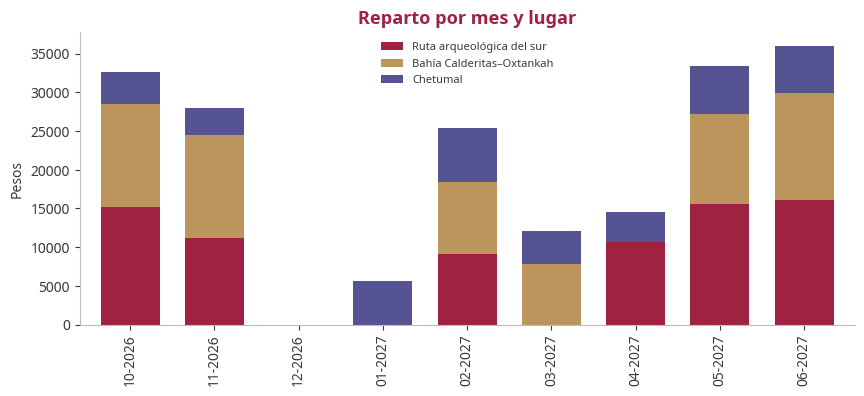

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.8))
tabla = sol["plan"].pivot_table(index="periodo", columns="lugar", values="pesos", aggfunc="sum")
tabla.index = [f"{p:%m-%Y}" for p in tabla.index]
tabla[["Ruta arqueológica del sur", "Bahía Calderitas–Oxtankah", "Chetumal"]].plot.bar(stacked=True, ax=ax,
    color=[GUINDA, DORADO, "#565393"], width=0.7)
ax.set_ylabel("Pesos"); ax.set_title("Reparto por mes y lugar"); ax.legend(frameon=False, fontsize=8)
plt.show()

### 3. ¿Cuánto cuesta cada regla?
Se resuelve el modelo sin la regla y se compara. Además, el **precio sombra** (del LP con las $y$ fijas) dice cuántos
visitantes trae un peso más de holgura en esa regla.

In [10]:
display(pz.costo_de_reglas().round(2))
pz.precios_sombra(pz.resolver()).assign(por_cada_mil=lambda d: d.precio_sombra * 1000).round(4)

,regla,visitantes_con_regla,visitantes_sin_regla,costo_visitantes,costo_pct
0,Cero anuncio en temporada alta,956.78,956.78,0.0,0.00
1,Tope de capacidad probada,956.78,956.78,0.0,0.00
2,Piso de equidad de 15 % por lugar,956.78,956.78,0.0,0.00
3,Tope de 70 % por canal,956.78,1239.07,282.3,29.51


,regla,precio_sombra,holgura,por_cada_mil
0,presupuesto,0.0016,-0.0,1.5898
1,equidad_0,-0.0000,-0.0,-0.0000
2,equidad_1,-0.0000,-28125.0,-0.0000
3,equidad_2,-0.0000,-75000.0,-0.0000
4,canal_Google,-0.0000,75000.0,-0.0000
5,canal_Facebook,0.0050,-0.0,5.0186


### 4. Frontera de Pareto: visitantes contra espacio libre
$\varepsilon$-restricción: ningún mes con anuncio puede pasar de $\varepsilon$ veces su capacidad probada en el
escenario probable.

,ocupacion_max,estado,visitantes_esperados,lugares_sin_meses
0,1.00,Optimal,956.775973,None
1,0.90,Optimal,956.775973,None
2,0.80,Optimal,956.775973,None
3,0.70,Optimal,956.775981,Chetumal
4,0.60,Optimal,956.775983,Chetumal
5,0.50,Optimal,956.775980,Chetumal
6,0.45,Optimal,956.775988,Chetumal
7,0.40,Optimal,956.775990,"Chetumal, Bahía Calderitas–Oxtankah"
8,0.35,Optimal,536.867740,"Chetumal, Bahía Calderitas–Oxtankah"
9,0.30,Optimal,0.000000,"Chetumal, Bahía Calderitas–Oxtankah, Ruta arqueológica d..."


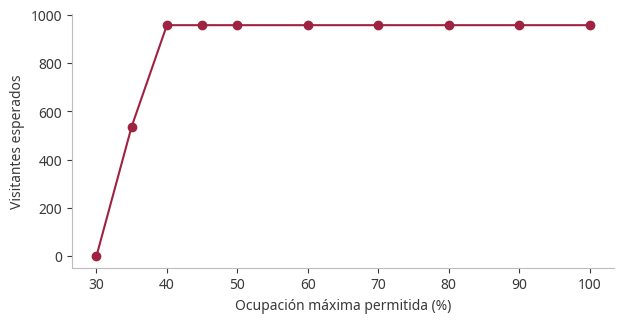

In [11]:
par = pz.pareto(); display(par)
fig, ax = plt.subplots(figsize=(7, 3.3))
ax.plot(par.ocupacion_max * 100, par.visitantes_esperados, marker="o", color=GUINDA)
ax.set_xlabel("Ocupación máxima permitida (%)"); ax.set_ylabel("Visitantes esperados"); plt.show()

### 5. Sensibilidad: ¿qué pasa si los supuestos están mal?

In [12]:
pz.sensibilidad().round(1)

,caso,presupuesto_periodo,visitantes_esperados,pesos_por_visitante,pct_Chetumal,pct_Bahía Calderitas–Oxtankah,pct_Ruta arqueológica del sur,pct_Google,pct_Facebook,pausas_en_escenarios
0,Base,187500.0,956.8,196.0,21.6,36.9,41.5,30.0,70.0,0
1,Conversión Facebook 3 %,187500.0,542.0,346.0,21.6,36.9,41.5,30.0,70.0,0
2,Conversión Facebook 6.38% (mediana de industrias),187500.0,1051.8,178.3,21.6,36.9,41.5,30.0,70.0,0
3,Clic de Facebook a $0.42 (LocaliQ 2026),187500.0,1142.6,164.1,21.6,36.9,41.5,30.0,70.0,0
4,Golpe de tormenta 25 %,187500.0,956.8,196.0,22.0,36.8,41.2,30.0,70.0,0
5,Golpe de tormenta 50 %,187500.0,956.8,196.0,21.9,36.9,41.2,30.0,70.0,0
6,"Presupuesto $500,000 al año",375000.0,1913.6,196.0,21.6,36.9,41.5,30.0,70.0,0
7,"Presupuesto $1,000,000 al año",750000.0,3827.1,196.0,21.6,36.9,41.5,30.0,70.0,0


### 6. Qué se concluye
1. **Con $250,000 al año la campaña trae unos 957 visitantes** en los 9 meses con pronóstico (≈ $196 por visitante).
   Con conversión de Facebook de 3 %, 542; con la mediana de industrias, 1,052.
2. **Las reglas ambientales no cuestan visitantes a esta escala:** temporada alta, capacidad y equidad cuestan 0. La
   campaña es chica frente al espacio que hay. La única regla que cuesta es el tope por canal (−29.5 %), y es una
   decisión de riesgo (no depender de una sola plataforma), no de sustentabilidad.
3. **Se puede prometer más espacio sin perder visitantes:** ningún mes con anuncio pasa del 40 % de su capacidad
   probada, y los visitantes no cambian. Por debajo de 40 % la frontera cae (35 % → 537; 30 % → 0).
4. **El reparto no depende del supuesto de tormentas** (golpe 0/25/50 %): los meses con riesgo ya están fuera.
5. **Limitaciones declaradas:** costos de EE. UU.; conversión de Facebook supuesta; cada conversión cuenta como un
   visitante (cota alta); sin dato de cómo se agota la audiencia (por eso el desempate proporcional); el plan cubre
   oct-2026 a jun-2027 porque después no hay pronóstico.

### El plan que pasa a la Torre
Se guarda el reparto (etapa 1) en `datos/gold/`, de donde lo lee la Torre para saber cuánto gastar cada semana.

In [13]:
from torre.campana import presupuesto
presupuesto.construir();

Meses con pronóstico: 2026-10-01 → 2027-06-01 (9); presupuesto del periodo $187,500; 17.06 pesos por dólar (2026-08-01)
  Google: clic $36.17 MXN, conversión 5.75% → 1.59 por cada $1,000
  Facebook: clic $8.70 MXN, conversión 5.75% → 6.61 por cada $1,000
Visitantes esperados: 956.8; desvío del reparto proporcional 0.0000; meses permitidos 20 de 27
lugar      Bahía Calderitas–Oxtankah         Chetumal         Ruta arqueológica del sur        
canal                       Facebook  Google Facebook  Google                  Facebook  Google
periodo                                                                                        
2026-10-01                    9293.0  3983.0   2893.0  1240.0                   10624.0  4553.0
2026-11-01                    9305.0  3988.0   2502.0  1072.0                    7802.0  3344.0
2026-12-01                       0.0     0.0      0.0     0.0                       0.0     0.0
2027-01-01                       0.0     0.0   3955.0  1695.0             

### El código de la Parte B
Cada celda de código de abajo es un archivo del paquete `torre`, completo y sin cambios (con su encabezado: qué hace, por qué así, de qué datos sale y a qué decisión alimenta). Al correrla, la celda queda registrada como ese módulo y las celdas siguientes lo usan.

- **`torre.base.silver_iter`** — Limpia el Censo de Población y Vivienda 2020 de Quintana Roo por localidad (INEGI, ITER) y lo guarda en Silver: población, viviendas habitadas, servicios de las viviendas (agua entubada, drenaje, electricidad) y coordenadas en grados decimales. A cada localidad le pone la región de la campaña a la que pertenece (o "referencia"), para calcular turistas por residente.
- **`torre.radar.panel`** — Pieza 1 de la Fase 4. Arma el panel mensual del Radar: una fila por lugar y mes (2022-01 al último mes publicado) con las variables candidatas del índice de presión turística, y una tabla de cobertura que dice cuántos meses con dato tiene cada lugar en cada variable.
- **`torre.radar.markov`** — Pieza 3b de la Fase 4. Cadena de Markov semanal de los 7 centros turísticos del norte que mide DataTur: estima la probabilidad de pasar de tranquilo / concurrido / saturado a cada estado de una semana a la siguiente y, con ella, la probabilidad de que cada centro esté saturado en 1 a 8 semanas.
- **`torre.envivo.senales`** — Arma una fila por semana (lunes) con las cuatro señales que vigila la Torre, elegidas por el equipo el 02-oct-2026 (*Las decisiones, fase por fase* (PDF)): 1. Ocupación del norte: Cancún y Riviera Maya (DataTur semanal), con su estado según los cortes del Radar (p50/p90 de todas las semanas de Quintana Roo) y su promedio móvil de 4 semanas (ventana deslizante en Spark). 2. Tormentas cerca: algún punto de HURDAT2 que afecta al sur esa semana (≤ 200 km de Chetumal, ≥ 34 nudos, la regla de la Fase 5). 2026 todavía no está publicado: se marca SIN DATO, no "sin tormenta". 3. Clima raro: Isolation Forest sobre el clima semanal de Chetumal y Kohunlich (lluvia, lluvia del peor día, viento y calor, más la época del año), entrenado con 2019–2021 y aplicado a 2022–2026. 4. Llegadas del sur: el dato real de cada mes contra el rango del 90 % del pronóstico a un mes del modelo elegido (backtest de la Fase 5). Se supone que el dato de un mes se conoce al empezar el siguiente (supuesto declarado: en la realidad se publica con 1–2 meses de retraso).
- **`torre.envivo.motor`** — Motor de reglas de la Torre: con las señales de una semana decide, para cada lugar del sur, si su anuncio se enciende, se pausa o no toca (temporada alta / fuera del plan), cuánto dinero se gasta y cuánto pasa a la siguiente semana; y si se enciende "¿Ibas al norte?" y hacia qué lugar del sur.
- **`torre.envivo.torre`** — Reproduce las 239 semanas reales (ene-2022 → jul-2026) como si llegaran una por una: 1. Escribe cada semana de señales como un archivo JSON en datos/gold/envivo_entrada/, en orden. 2. Spark Structured Streaming lee esa carpeta con maxFilesPerTrigger = 1 (una semana por lote) y, en cada lote (foreachBatch), el motor de reglas decide qué anuncio se enciende o se pausa. 3. Guarda todas las decisiones en Gold y comprueba que las semanas llegaron en orden.

In [14]:
%%modulo torre.base.silver_iter
# Autor: Brandon Uriel García Sánchez
# Módulo: Base de datos
# Qué hace:          Limpia el Censo de Población y Vivienda 2020 de Quintana Roo por localidad (INEGI, ITER) y lo
#                    guarda en Silver: población, viviendas habitadas, servicios de las viviendas (agua entubada,
#                    drenaje, electricidad) y coordenadas en grados decimales. A cada localidad le pone la región de la
#                    campaña a la que pertenece (o "referencia"), para calcular turistas por residente.
# Por qué así:       - Decisión del equipo (28-sep-2026): la población de cada región se mide POR LOCALIDAD, no por
#                      municipio, porque 4 de las 5 regiones están en Othón P. Blanco (233,648 habitantes) y a nivel
#                      municipio no se podrían distinguir. Alternativa descartada: municipio.
#                    - La lista de localidades de cada región es un criterio del proyecto; está en REGION_LOCALIDADES
#                      con su justificación y se defiende en docs/decisiones/05-planteamiento.md.
#                    - Servicios de vivienda = criterio 4 de selección (fragilidad de servicios: agua, drenaje).
#                    - INEGI reserva algunos valores con "*" (confidencialidad) o "N/D": se guardan como nulos con
#                      reservado_flag, nunca como 0 (regla de oro 1).
#                    - Se conservan solo las filas de localidad: las de total estatal (MUN 000), total municipal
#                      (LOC 0000) y "localidades de una o dos viviendas" (LOC 9998/9999) se separan con tipo_fila.
# Datos de entrada:  datos/bronze/iter/<fecha>/iter_23_cpv2020_csv.zip (D7).
# Alimenta a:        Fase 3 (tabla de criterios: turistas por residente y servicios), A1 Radar (presión por residente)
#                    y el mapa de la página (coordenadas de cada región).

import re
import zipfile

import pandas as pd

from torre.base.entorno import RAIZ, crear_spark

BRONZE_ITER = RAIZ / "datos" / "bronze" / "iter"
SILVER_ITER = RAIZ / "datos" / "silver" / "iter"
COLUMNAS = {"MUN": "cve_mun", "NOM_MUN": "municipio", "LOC": "cve_loc", "NOM_LOC": "localidad", "LATITUD": "latitud_gms",
            "LONGITUD": "longitud_gms", "POBTOT": "poblacion", "TVIVPARHAB": "viviendas_habitadas",
            "VPH_AGUADV": "viviendas_con_agua", "VPH_DRENAJ": "viviendas_con_drenaje", "VPH_C_ELEC": "viviendas_con_luz"}
NUMERICAS = ["poblacion", "viviendas_habitadas", "viviendas_con_agua", "viviendas_con_drenaje", "viviendas_con_luz"]

# Región de la campaña → localidades (clave de municipio, clave de localidad, nombre esperado). El nombre se comprueba
# al construir: si INEGI cambia una clave, el proceso se detiene en lugar de asignar la localidad equivocada.
REGION_LOCALIDADES = {
    "Chetumal": [("004", "0001", "Chetumal")],
    "Bahía Calderitas–Oxtankah": [("004", "0016", "Calderitas")],               # Oxtankah está junto a Calderitas
    "Laguna Milagros–Xul-Ha": [("004", "0114", "Xul-Ha"), ("004", "0037", "Huay-Pix")],  # las dos orillas habitadas
    "Ruta arqueológica del sur": [("004", "0064", "Nicolás Bravo"), ("004", "0245", "Morocoy"),
                                  ("004", "0033", "Francisco Villa")],         # poblados de acceso a Kohunlich y Dzibanché
    "Maya Ka'an + Kantemó": [("002", "0001", "Felipe Carrillo Puerto"), ("002", "0250", "Tihosuco"),
                             ("002", "0239", "Señor"), ("002", "0044", "Chunhuhub"), ("006", "0076", "Kantemó")],
    # Referencia (no se promueve): las cabeceras donde hoy está el turista.
    "Cancún (referencia)": [("005", "0001", "Cancún")],
    "Playa del Carmen (referencia)": [("008", "0001", "Playa del Carmen")],
    "Tulum (referencia)": [("009", "0001", "Tulum")],
}


def _grados(texto) -> float | None:
    """Convierte '88°17\\'52.436" W' a grados decimales (−88.2979). Así publica el ITER las coordenadas."""
    if not isinstance(texto, str):
        return None
    m = re.match(r"(\d+)°(\d+)'([\d.]+)\"\s*([NSEW])", texto.strip())
    if not m:
        return None
    g, mi, s, h = m.groups()
    valor = int(g) + int(mi) / 60 + float(s) / 3600
    return -valor if h in "SW" else valor


def leer_iter() -> pd.DataFrame:
    zipf = sorted(BRONZE_ITER.glob("*/iter_23_cpv2020_csv.zip"))[-1]
    with zipfile.ZipFile(zipf) as z:
        nombre = next(n for n in z.namelist() if "conjunto_de_datos" in n and n.endswith(".csv"))
        d = pd.read_csv(z.open(nombre), dtype=str)
    faltan = set(COLUMNAS) - set(d.columns)
    if faltan:
        raise ValueError(f"ITER: no existen las columnas {sorted(faltan)}; revisar el diccionario de datos")
    d = d[list(COLUMNAS)].rename(columns=COLUMNAS)
    d["tipo_fila"] = "localidad"
    d.loc[d.cve_loc == "0000", "tipo_fila"] = "total_municipal"
    d.loc[d.cve_mun == "000", "tipo_fila"] = "total_estatal"
    d.loc[d.cve_loc.isin(["9998", "9999"]), "tipo_fila"] = "localidades_pequenas"
    reservado = d[NUMERICAS].isin(["*", "N/D"]).any(axis=1)
    for c in NUMERICAS:
        d[c] = pd.to_numeric(d[c].where(~d[c].isin(["*", "N/D"])), errors="coerce").astype("Int64")
    d["reservado_flag"] = reservado
    d["latitud"] = d.latitud_gms.map(_grados)
    d["longitud"] = d.longitud_gms.map(_grados)
    d["archivo"] = str(zipf.relative_to(RAIZ))
    return d.drop(columns=["latitud_gms", "longitud_gms"])


def asignar_regiones(d: pd.DataFrame) -> pd.DataFrame:
    d["region_campana"] = None
    d["papel_campana"] = None
    for region, localidades in REGION_LOCALIDADES.items():
        for mun, loc, esperado in localidades:
            fila = (d.cve_mun == mun) & (d.cve_loc == loc)
            if fila.sum() != 1 or d.loc[fila, "localidad"].iloc[0] != esperado:
                encontrado = d.loc[fila, "localidad"].tolist()
                raise ValueError(f"ITER: {mun}-{loc} debía ser {esperado} y es {encontrado}; no se asigna a ciegas")
            d.loc[fila, "region_campana"] = region.replace(" (referencia)", "")
            d.loc[fila, "papel_campana"] = "referencia" if "(referencia)" in region else "promovida"
    return d


def construir_silver_iter(spark=None):
    spark = spark or crear_spark("silver-iter")
    d = asignar_regiones(leer_iter())
    spark.createDataFrame(d.astype({c: "float64" for c in NUMERICAS}).astype(
        {"region_campana": "object", "papel_campana": "object"})).write.mode("overwrite").parquet(str(SILVER_ITER))
    loc = d[d.tipo_fila == "localidad"]
    estatal = int(d.loc[d.tipo_fila == "total_estatal", "poblacion"].iloc[0])
    print(f"ITER Silver: {len(d):,} filas; {len(loc):,} localidades; población estatal {estatal:,}; "
          f"{int(loc.reservado_flag.sum()):,} localidades con algún dato reservado por INEGI")
    resumen = (d[d.region_campana.notna()].groupby(["papel_campana", "region_campana"])
               [["poblacion", "viviendas_habitadas", "viviendas_con_agua", "viviendas_con_drenaje"]].sum())
    print(resumen.to_string())
    return d


In [15]:
%%modulo torre.radar.panel
# Autor: Brandon Uriel García Sánchez
# Módulo: Radar
# Qué hace:          Pieza 1 de la Fase 4. Arma el panel mensual del Radar: una fila por lugar y mes (2022-01 al último
#                    mes publicado) con las variables candidatas del índice de presión turística, y una tabla de
#                    cobertura que dice cuántos meses con dato tiene cada lugar en cada variable.
# Por qué así:       - Mensual y no semanal: el sur solo se publica por mes (SITUR-Q, INAH). La ocupación semanal de
#                      DataTur (solo norte) se usa aparte, en la cadena de Markov (pieza 3).
#                    - Visitantes a zonas arqueológicas: se toman del INAH zona por zona y NO de SITUR-Q, porque la
#                      serie "zonas arqueológicas" de SITUR-Q es el mismo dato del INAH agrupado por destino (Chetumal
#                      2025 = 39,459 = Oxtankah 11,017 + Kohunlich 21,850 + Dzibanché 6,592). Usar las dos contaría dos
#                      veces a los mismos visitantes. Cada zona se asigna a UN solo lugar (ZONA_A_LUGAR).
#                    - Sin avión: un aeropuerto no es un destino (a Cancún llega gente que va a toda la Riviera) y
#                      además la serie termina en 2024 (regla 6 de Silver).
#                    - Sin zonas de SITUR-Q (Riviera Maya, Grand Costa Maya, Caribe Mexicano): suman lugares que ya
#                      están en el panel (ver planteamiento.py, comprobar_zonas()).
#                    - Un hueco se queda como nulo; no se rellena (regla de oro 1).
# Datos de entrada:  datos/silver/{siturq, inah, iter}.
# Alimenta a:        Índice de presión y estados (pieza 2, indice.py) → decisión de la campaña: dónde anunciar y dónde
#                    no (un lugar "saturado" no se promueve).

from pathlib import Path

import pandas as pd

from torre.base.silver_iter import REGION_LOCALIDADES

RAIZ = Path(__file__).resolve().parents[3]
SILVER = RAIZ / "datos" / "silver"
GOLD = RAIZ / "datos" / "gold"
DESDE = "2022-01-01"  # primer mes con cuartos de hotel publicados en SITUR-Q

# Lugares del Radar: los 5 de la campaña + los destinos de SITUR-Q del resto del estado (referencia para la escala
# común de percentiles, decisión del equipo del 28-sep-2026).
LUGARES_5 = ["Chetumal", "Bahía Calderitas–Oxtankah", "Ruta arqueológica del sur", "Maya Ka'an + Kantemó",
             "Laguna Milagros–Xul-Ha"]
SITURQ_A_LUGAR = {"Chetumal": "Chetumal", "Maya Ka'an": "Maya Ka'an + Kantemó",  # los 2 de la campaña con serie propia
                  "Cancún": "Cancún", "Costa Mujeres": "Costa Mujeres", "Isla Mujeres": "Isla Mujeres",
                  "Holbox": "Holbox", "Cozumel": "Cozumel", "Puerto Morelos": "Puerto Morelos",
                  "Playa del Carmen": "Playa del Carmen", "Tulum": "Tulum", "Bacalar": "Bacalar", "Mahahual": "Mahahual"}
# Cada zona arqueológica del INAH va a un solo lugar. Misma agrupación que SITUR-Q, salvo Ichkabal: SITUR-Q la suma a
# Bacalar, pero en el proyecto es parte de la Ruta arqueológica del sur (decisión de regiones, 01-regiones.md).
ZONA_A_LUGAR = {"Z.A. de Oxtankah": "Bahía Calderitas–Oxtankah", "Z.A. de Kohunlich": "Ruta arqueológica del sur",
                "Z.A. de Dzibanché-Kinichná": "Ruta arqueológica del sur", "Z.A de Ichkabal": "Ruta arqueológica del sur",
                "Z.A. de Chacchoben": "Bacalar", "Z.A. de Tulum": "Tulum", "Z.A. de Cobá": "Tulum", "Z.A. de Muyil": "Tulum",
                "Z.A. de Xelhá": "Tulum", "Z.A. de San Gervasio": "Cozumel", "Z.A. de El Rey": "Cancún",
                "Z.A. de El Meco": "Costa Mujeres", "Z.A. de Xcaret": "Playa del Carmen"}
# Zonas que el INAH lista pero que nunca registran visitantes (0 en todos sus meses, 2016–2023): no son un destino.
# Si algún día registran visitantes, _inah() se detiene para asignarlas a un lugar.
ZONAS_SIN_VISITA = {"Z.A. de Chakanbakán"}
# Localidades del Censo para la población de los lugares de referencia (los 5 usan REGION_LOCALIDADES).
# Costa Mujeres no es una localidad del Censo: queda sin población (se declara).
LOCALIDAD_REFERENCIA = {"Cancún": [("005", "0001")], "Isla Mujeres": [("003", "0001")], "Holbox": [("007", "0012")],
                        "Cozumel": [("001", "0001")], "Puerto Morelos": [("011", "0001")],
                        "Playa del Carmen": [("008", "0001")], "Tulum": [("009", "0001")], "Bacalar": [("010", "0001")],
                        "Mahahual": [("004", "0053")]}
# (indicador, variable) de SITUR-Q → columna del panel. OJO: "ocupacion_hotelera" trae TRES filas por mes (cuartos-noche
# disponibles, cuartos-noche ocupados y el porcentaje). La primera versión del panel las sumaba (corrección del
# 29-sep-2026). Ahora se guardan los cuartos-noche y el porcentaje se recalcula como ocupados ÷ disponibles, igual que en
# la tabla de criterios (nunca se suman ni se promedian porcentajes).
INDICADORES = {("tren_maya_descenso", "total"): "llegadas_tren", ("cruceristas", "cruceristas"): "cruceristas",
               ("frontera_belice", "total_cruces_fronterizos"): "cruces_belice",
               ("ocupacion_hotelera", "total_de_habitaciones_ocupadas"): "cuartos_noche_ocupados",
               ("ocupacion_hotelera", "numero_de_habitaciones_disponibles"): "cuartos_noche_disponibles",
               ("habitaciones", "total_de_habitaciones"): "cuartos", ("centros_hospedaje", "total_de_hoteles"): "hoteles"}
VARIABLES = ["llegadas_tren", "cruceristas", "cruces_belice", "visitantes_inah", "ocupacion_pct",
             "ocupacion_siturq_pct", "ocupacion_datatur_pct", "cuartos_noche_ocupados", "cuartos_noche_disponibles",
             "cuartos", "hoteles"]
# Ocupación de DataTur (semanal, 2022–2026) para los 4 lugares del panel que DataTur mide con el mismo nombre. SITUR-Q
# dejó de publicar ocupación en 2025; sin esta fuente el Radar calificaba a Cancún "tranquilo" en jul-2026 (IPT 0.025)
# cuando DataTur marca 68.8 %. Decisión del equipo del 29-sep-2026 (opción D, 08-radar.md). Cada lugar usa UNA sola
# fuente de ocupación en toda su historia (ocupacion_pct), para no contar la ocupación dos veces ni cambiar de fuente
# a media serie. Akumal, Playacar y "Riviera Maya" de DataTur no son lugares del panel y no se usan.
DATATUR_A_LUGAR = {"Cancun": "Cancún", "Playa Del Carmen": "Playa del Carmen", "Cozumel": "Cozumel",
                   "Isla Mujeres": "Isla Mujeres"}


def _siturq() -> pd.DataFrame:
    """Variables de SITUR-Q por lugar y mes (sin huecos: el hueco queda como ausencia de fila → nulo en el panel)."""
    s = pd.read_parquet(SILVER / "siturq")
    llave = pd.Series(list(zip(s.indicador.astype(str), s.variable)), index=s.index)
    s = s[~s.hueco_flag & s.unidad.isin(SITURQ_A_LUGAR) & llave.isin(INDICADORES)]
    s = s.assign(lugar=s.unidad.map(SITURQ_A_LUGAR), columna=llave[s.index].map(INDICADORES),
                 periodo=pd.to_datetime(s.periodo.astype(str)))
    repetidas = s.duplicated(["lugar", "periodo", "columna"])
    if repetidas.any():  # una variable debe traer una sola fila por lugar y mes; si no, se detiene (no se suma a ciegas)
        raise ValueError(f"Filas repetidas en SITUR-Q: {s[repetidas][['lugar', 'periodo', 'columna']].head().to_dict('records')}")
    t = s.pivot(index=["lugar", "periodo"], columns="columna", values="valor").reset_index()
    t["ocupacion_siturq_pct"] = 100 * t.cuartos_noche_ocupados / t.cuartos_noche_disponibles
    return t


def _datatur() -> pd.DataFrame:
    """Ocupación mensual desde DataTur semanal: Σ cuartos ocupados ÷ Σ cuartos disponibles de las semanas que empiezan
    en el mes (nunca el promedio de porcentajes). Una semana que cruza de mes cuenta en el mes de su lunes (se declara)."""
    o = pd.read_parquet(SILVER / "datatur_ocupacion",
                        columns=["centro", "es_qroo", "frecuencia", "periodo", "cuartos_ocupados", "cuartos_disponibles"])
    o = o[o.es_qroo & (o.frecuencia == "semanal") & o.centro.isin(DATATUR_A_LUGAR)]
    o = o.assign(lugar=o.centro.map(DATATUR_A_LUGAR),
                 periodo=pd.to_datetime(o.periodo.astype(str)).dt.to_period("M").dt.to_timestamp())
    m = o.groupby(["lugar", "periodo"], as_index=False)[["cuartos_ocupados", "cuartos_disponibles"]].sum()
    m["ocupacion_datatur_pct"] = 100 * m.cuartos_ocupados / m.cuartos_disponibles
    return m[["lugar", "periodo", "ocupacion_datatur_pct"]]


def _inah() -> pd.DataFrame:
    """Visitantes (nacionales + extranjeros) a zonas arqueológicas por lugar y mes."""
    i = pd.read_parquet(SILVER / "inah", columns=["nombre", "clasificacion", "periodo", "visitantes", "es_qroo"])
    i = i[i.es_qroo & (i.clasificacion == "Zona Arqueológica")]
    sin_visita = i[i.nombre.isin(ZONAS_SIN_VISITA)]
    if sin_visita.visitantes.sum() > 0:
        raise ValueError(f"Una zona de ZONAS_SIN_VISITA ya registra visitantes: {sorted(sin_visita[sin_visita.visitantes > 0].nombre.unique())}")
    i = i[~i.nombre.isin(ZONAS_SIN_VISITA)]
    faltan = set(i.nombre) - set(ZONA_A_LUGAR)
    if faltan:  # regla de oro 5: una zona sin lugar asignado detiene el paso
        raise ValueError(f"Zonas del INAH sin lugar asignado en ZONA_A_LUGAR: {sorted(faltan)}")
    i = i.assign(lugar=i.nombre.map(ZONA_A_LUGAR), periodo=pd.to_datetime(i.periodo.astype(str)))
    return i.groupby(["lugar", "periodo"], as_index=False).visitantes.sum().rename(columns={"visitantes": "visitantes_inah"})


def _poblacion() -> pd.Series:
    c = pd.read_parquet(SILVER / "iter", columns=["cve_mun", "cve_loc", "poblacion", "tipo_fila"])
    c = c[c.tipo_fila == "localidad"]
    localidades = {r: [(m, l) for m, l, _ in locs] for r, locs in REGION_LOCALIDADES.items() if r in LUGARES_5}
    localidades |= LOCALIDAD_REFERENCIA
    return pd.Series({lugar: c[c.set_index(["cve_mun", "cve_loc"]).index.isin(locs)].poblacion.sum()
                      for lugar, locs in localidades.items()}, name="poblacion")


def panel_mensual() -> pd.DataFrame:
    """Una fila por lugar × mes, de DESDE al último mes publicado. Las celdas sin dato quedan nulas."""
    datos = _siturq().merge(_inah(), on=["lugar", "periodo"], how="outer")
    lugares = LUGARES_5 + [l for l in SITURQ_A_LUGAR.values() if l not in LUGARES_5]
    meses = pd.date_range(DESDE, datos.periodo.max(), freq="MS")
    datos = datos.merge(_datatur(), on=["lugar", "periodo"], how="left")
    datatur = datos.lugar.isin(DATATUR_A_LUGAR.values())
    datos["ocupacion_pct"] = datos.ocupacion_datatur_pct.where(datatur, datos.ocupacion_siturq_pct)
    base = pd.MultiIndex.from_product([lugares, meses], names=["lugar", "periodo"]).to_frame(index=False)
    p = base.merge(datos, on=["lugar", "periodo"], how="left")
    for v in VARIABLES:
        if v not in p:
            p[v] = pd.NA
    p["fuente_ocupacion"] = p.lugar.isin(DATATUR_A_LUGAR.values()).map({True: "DataTur", False: "SITUR-Q"})
    p = p.merge(_poblacion(), left_on="lugar", right_index=True, how="left")
    p["es_de_los_5"] = p.lugar.isin(LUGARES_5)
    return p[["lugar", "es_de_los_5", "periodo", *VARIABLES, "fuente_ocupacion", "poblacion"]].sort_values(
        ["lugar", "periodo"], ignore_index=True)


def cobertura(panel: pd.DataFrame) -> pd.DataFrame:
    """Meses con dato por lugar y variable (de cuántos posibles). Sirve para ver qué variables pueden entrar al índice."""
    tabla = panel.groupby("lugar")[VARIABLES].count()
    tabla.insert(0, "meses_posibles", panel.groupby("lugar").size())
    return tabla.loc[LUGARES_5 + [l for l in tabla.index if l not in LUGARES_5]]


def guardar() -> Path:
    GOLD.mkdir(parents=True, exist_ok=True)
    salida = GOLD / "radar_panel_mensual.parquet"
    panel_mensual().to_parquet(salida, index=False)
    return salida


In [16]:
%%modulo torre.radar.markov
# Autor: Brandon Uriel García Sánchez
# Módulo: Radar
# Qué hace:          Pieza 3b de la Fase 4. Cadena de Markov semanal de los 7 centros turísticos del norte que mide
#                    DataTur: estima la probabilidad de pasar de tranquilo / concurrido / saturado a cada estado de una
#                    semana a la siguiente y, con ella, la probabilidad de que cada centro esté saturado en 1 a 8 semanas.
# Por qué así:       - Decisión del equipo (29-sep-2026): semanal y solo el norte, como dice el plan (Markov en semanas,
#                      el Pronóstico en meses; B.2). Descartadas: mensual para todos (repetía al clasificador de la pieza 3
#                      y se encimaba con la Fase 5) y las dos a la vez.
#                    - El sur no tiene datos semanales: la cadena cubre solo la referencia del norte y se dice.
#                    - Estados con percentiles comunes (misma decisión que el Radar): p50 y p90 de la ocupación semanal de
#                      los 7 centros juntos. La ocupación de cada semana es cuartos ocupados ÷ disponibles.
#                    - Una matriz para los 7 centros juntos (más de 1,600 transiciones). Se prueba contra la persistencia
#                      y contra la frecuencia simple de cada estado en las últimas 52 semanas, sin verlas al estimar.
# Datos de entrada:  datos/silver/datatur_ocupacion (semanal, 2022–2026).
# Alimenta a:        Campaña: cuando se espera que el norte se sature en las próximas semanas, es el momento de
#                    ofrecerle el sur a ese turista; Torre en vivo (Fase 7) usa la probabilidad semana a semana.

from pathlib import Path

import numpy as np
import pandas as pd

from torre.radar.panel import GOLD, SILVER

ESTADOS = ["tranquilo", "concurrido", "saturado"]
CORTES = (0.50, 0.90)
SEMANAS_PRUEBA = 52
HORIZONTE = 8


def ocupacion_semanal() -> pd.DataFrame:
    o = pd.read_parquet(SILVER / "datatur_ocupacion",
                        columns=["centro", "es_qroo", "frecuencia", "periodo", "cuartos_ocupados", "cuartos_disponibles"])
    o = o[o.es_qroo & (o.frecuencia == "semanal")].copy()
    o["semana"] = pd.to_datetime(o.periodo.astype(str))
    o["ocupacion_pct"] = 100 * o.cuartos_ocupados / o.cuartos_disponibles
    return o[["centro", "semana", "ocupacion_pct"]].sort_values(["centro", "semana"], ignore_index=True)


def estados(o: pd.DataFrame) -> tuple[pd.DataFrame, tuple[float, float]]:
    u50, u90 = np.quantile(o.ocupacion_pct, CORTES)
    o = o.copy()
    o["estado"] = np.select([o.ocupacion_pct < u50, o.ocupacion_pct <= u90], ESTADOS[:2], default=ESTADOS[2])
    return o, (float(u50), float(u90))


def transiciones(o: pd.DataFrame) -> pd.DataFrame:
    """Pares (estado de la semana t, estado de la semana t+1) del mismo centro, solo si las semanas son consecutivas."""
    o = o.sort_values(["centro", "semana"])
    sig = o.groupby("centro").shift(-1)
    consecutiva = (sig.semana - o.semana) == pd.Timedelta(days=7)
    return pd.DataFrame({"centro": o.centro, "semana": o.semana, "desde": o.estado, "hacia": sig.estado})[consecutiva]


def matriz(tr: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    """p_ij = n_ij / Σ_j n_ij (máxima verosimilitud de una cadena de Markov: contar y dividir)."""
    n = pd.crosstab(tr.desde, tr.hacia).reindex(index=ESTADOS, columns=ESTADOS, fill_value=0)
    return n.div(n.sum(axis=1), axis=0), n


def estacionaria(P: pd.DataFrame) -> pd.Series:
    """π tal que π = π P: la proporción de semanas en cada estado a largo plazo (vector propio de valor 1)."""
    val, vec = np.linalg.eig(P.to_numpy().T)
    v = np.real(vec[:, np.argmin(np.abs(val - 1))])
    return pd.Series(v / v.sum(), index=ESTADOS)


def a_k_semanas(P: pd.DataFrame, estado: str, k: int) -> pd.Series:
    """π_{t+k} = π_t P^k, con π_t = 1 en el estado actual."""
    pi = pd.Series(0.0, index=ESTADOS)
    pi[estado] = 1.0
    return pd.Series(pi.to_numpy() @ np.linalg.matrix_power(P.to_numpy(), k), index=ESTADOS)


def backtest(o: pd.DataFrame, k_lista=(1, 4, 8)) -> pd.DataFrame:
    """Para cada semana de prueba (las últimas 52), estima P solo con transiciones anteriores y predice k semanas
    adelante. Puntaje de Brier: promedio de Σ_j (p_j − 1[y=j])², 0 es perfecto. Se compara contra la persistencia
    (probabilidad 1 al estado actual) y contra la frecuencia simple de cada estado."""
    tr = transiciones(o)
    corte = o.semana.max() - pd.Timedelta(weeks=SEMANAS_PRUEBA)
    por_centro = {c: g.set_index("semana").estado for c, g in o.groupby("centro")}
    filas = []
    for k in k_lista:
        brier = {"Markov": [], "Persistencia": [], "Frecuencia simple": []}
        aciertos = {"Markov": 0, "Persistencia": 0, "Frecuencia simple": 0}
        n = 0
        for semana in sorted(o.loc[o.semana > corte, "semana"].unique()):
            ant = tr[tr.semana + pd.Timedelta(days=7) <= semana - pd.Timedelta(weeks=k - 1)]  # solo pasado conocido
            P, _ = matriz(ant)
            frec = o[o.semana <= semana - pd.Timedelta(weeks=k)].estado.value_counts(normalize=True).reindex(ESTADOS, fill_value=0)
            for c, serie in por_centro.items():
                origen = semana - pd.Timedelta(weeks=k)
                if origen not in serie.index or semana not in serie.index:
                    continue
                real = np.array([serie[semana] == e for e in ESTADOS], dtype=float)
                pers = np.array([serie[origen] == e for e in ESTADOS], dtype=float)
                pred = {"Markov": a_k_semanas(P, serie[origen], k).to_numpy(), "Persistencia": pers,
                        "Frecuencia simple": frec.to_numpy()}
                for nombre, p in pred.items():
                    brier[nombre].append(((p - real) ** 2).sum())
                    aciertos[nombre] += int(ESTADOS[int(np.argmax(p))] == serie[semana])
                n += 1
        for nombre in brier:
            filas.append({"k_semanas": k, "metodo": nombre, "brier": round(float(np.mean(brier[nombre])), 3),
                          "exactitud": round(aciertos[nombre] / n, 3), "casos": n})
    return pd.DataFrame(filas)


def correr() -> dict:
    o, cortes = estados(ocupacion_semanal())
    tr = transiciones(o)
    P, n = matriz(tr)
    ultima = o.semana.max()
    hoy = o[o.semana == ultima].set_index("centro")
    riesgo = pd.DataFrame({f"sem_{k}": {c: a_k_semanas(P, e, k)["saturado"] for c, e in hoy.estado.items()}
                           for k in range(1, HORIZONTE + 1)})
    riesgo.insert(0, "estado_hoy", hoy.estado)
    riesgo.insert(1, "ocupacion_hoy_pct", hoy.ocupacion_pct.round(1))
    GOLD.mkdir(parents=True, exist_ok=True)
    P.to_parquet(GOLD / "radar_markov_matriz.parquet")
    riesgo.reset_index(names="centro").assign(semana=ultima).to_parquet(GOLD / "radar_markov_riesgo.parquet", index=False)
    bt = backtest(o)
    bt.to_parquet(GOLD / "radar_markov_backtest.parquet", index=False)  # lo lee la sección de evidencia de la página
    return {"o": o, "cortes": cortes, "P": P, "n": n, "pi": estacionaria(P), "riesgo": riesgo, "ultima": ultima,
            "backtest": bt}


In [17]:
%%modulo torre.envivo.senales
# Autor: Brandon Uriel García Sánchez
# Módulo: Torre en vivo (A5, Fase 7)
# Qué hace:          Arma una fila por semana (lunes) con las cuatro señales que vigila la Torre, elegidas por el equipo el
#                    02-oct-2026 (docs/decisiones/20-torre-en-vivo.md):
#                    1. Ocupación del norte: Cancún y Riviera Maya (DataTur semanal), con su estado según los cortes del
#                       Radar (p50/p90 de todas las semanas de Quintana Roo) y su promedio móvil de 4 semanas (ventana
#                       deslizante en Spark).
#                    2. Tormentas cerca: algún punto de HURDAT2 que afecta al sur esa semana (≤ 200 km de Chetumal,
#                       ≥ 34 nudos, la regla de la Fase 5). 2026 todavía no está publicado: se marca SIN DATO, no "sin
#                       tormenta".
#                    3. Clima raro: Isolation Forest sobre el clima semanal de Chetumal y Kohunlich (lluvia, lluvia del
#                       peor día, viento y calor, más la época del año), entrenado con 2019–2021 y aplicado a 2022–2026.
#                    4. Llegadas del sur: el dato real de cada mes contra el rango del 90 % del pronóstico a un mes del
#                       modelo elegido (backtest de la Fase 5). Se supone que el dato de un mes se conoce al empezar el
#                       siguiente (supuesto declarado: en la realidad se publica con 1–2 meses de retraso).
# Por qué así:       - Isolation Forest y no un umbral fijo: El equipo pidió que no se fije a mano qué es "raro"; el bosque lo
#                      aprende de 3 años de clima real. La época del año entra como seno y coseno, para que un aguacero de
#                      septiembre no se marque raro solo por ser septiembre.
#                    - Entrena con años ANTES de la reproducción, para no usar el futuro (misma regla del origen móvil).
#                    - El sur no tiene ningún dato semanal oficial: por eso sus señales son clima, tormentas y llegadas
#                      mensuales; la ocupación semanal solo existe para el norte.
# Datos de entrada:  datos/silver/datatur_ocupacion (D2), huracanes (D9), clima_horario (D8);
#                    datos/gold/pronostico_backtest y pronostico_eleccion (Fase 5).
# Alimenta a:        torre.envivo.motor (qué anuncio se enciende o se pausa cada semana).

import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest

from torre.base.entorno import RAIZ, crear_spark
from torre.radar.markov import estados, ocupacion_semanal

SILVER = RAIZ / "datos" / "silver"
GOLD = RAIZ / "datos" / "gold"
SALIDA = GOLD / "envivo_senales.parquet"

NORTE = {"Cancun": "cancun", "Riviera Maya": "riviera"}
PUNTO_DE = {"Chetumal": "chetumal", "Bahía Calderitas–Oxtankah": "chetumal", "Ruta arqueológica del sur": "kohunlich"}
SERIE_DE = {"Chetumal": "Chetumal · cruces desde Belice",
            "Bahía Calderitas–Oxtankah": "Bahía Calderitas–Oxtankah · visitantes INAH",
            "Ruta arqueológica del sur": "Ruta arqueológica del sur · visitantes INAH"}
CLAVE = {"Chetumal": "chetumal", "Bahía Calderitas–Oxtankah": "bahia", "Ruta arqueológica del sur": "ruta"}
ENTRENA = ("2019-01-01", "2021-12-31")
ULTIMO_HURDAT = pd.Timestamp("2025-12-31")
VARIABLES_CLIMA = ["lluvia_mm", "lluvia_max_dia_mm", "viento_max_kmh", "temp_max_c", "epoca_sin", "epoca_cos"]


def lunes(f: pd.Series) -> pd.Series:
    f = pd.to_datetime(f)
    return (f - pd.to_timedelta(f.dt.weekday, unit="D")).dt.normalize()


# ---------- 1. Norte ----------
def norte(spark) -> tuple[pd.DataFrame, tuple[float, float]]:
    o, cortes = estados(ocupacion_semanal())
    o = o[o.centro.isin(NORTE)]
    # Promedio móvil de 4 semanas con una ventana deslizante de Spark (la semana y las 3 anteriores del mismo centro).
    from pyspark.sql import Window, functions as F
    # La semana viaja como texto: Spark convierte las fechas a su zona horaria y la unión de regreso fallaría.
    o["semana_txt"] = o.semana.dt.strftime("%Y-%m-%d")
    df = spark.createDataFrame(o[["centro", "semana_txt", "ocupacion_pct"]])
    w = Window.partitionBy("centro").orderBy("semana_txt").rowsBetween(-3, 0)
    m = df.withColumn("ocupacion_4sem", F.avg("ocupacion_pct").over(w)).toPandas()
    o = o.merge(m[["centro", "semana_txt", "ocupacion_4sem"]], on=["centro", "semana_txt"])
    filas = []
    for centro, clave in NORTE.items():
        x = o[o.centro == centro].set_index("semana")
        filas.append(x[["ocupacion_pct", "estado", "ocupacion_4sem"]].add_prefix(f"{clave}_"))
    return pd.concat(filas, axis=1).reset_index().rename(columns={"index": "semana"}), cortes


# ---------- 2. Tormentas ----------
def tormentas(semanas: pd.Series) -> pd.DataFrame:
    h = pd.read_parquet(SILVER / "huracanes", columns=["id_tormenta", "nombre", "fecha", "afecta_sur_flag"])
    h = h[h.afecta_sur_flag]
    h["semana"] = lunes(h.fecha)
    t = h.groupby("semana").agg(tormenta_nombre=("nombre", lambda n: ", ".join(sorted(set(n.str.title())))))
    r = pd.DataFrame({"semana": semanas})
    r = r.merge(t, on="semana", how="left")
    r["tormenta"] = r.tormenta_nombre.notna().astype(object)
    r.loc[r.semana > ULTIMO_HURDAT, "tormenta"] = None  # HURDAT2 2026 aún no se publica: no se sabe
    return r


# ---------- 3. Clima raro (Isolation Forest) ----------
def clima_semanal() -> pd.DataFrame:
    c = pd.read_parquet(SILVER / "clima_horario", columns=["punto", "fecha_hora_local", "temp_c", "lluvia_mm", "viento_kmh"])
    c = c[c.punto.isin(set(PUNTO_DE.values()))]
    c["dia"] = c.fecha_hora_local.dt.normalize()
    d = c.groupby(["punto", "dia"]).agg(lluvia=("lluvia_mm", "sum"), viento=("viento_kmh", "max"), temp=("temp_c", "max"))
    d = d.reset_index()
    d["semana"] = lunes(d.dia)
    s = d.groupby(["punto", "semana"]).agg(lluvia_mm=("lluvia", "sum"), lluvia_max_dia_mm=("lluvia", "max"),
                                            viento_max_kmh=("viento", "max"), temp_max_c=("temp", "max"),
                                            dias=("dia", "nunique")).reset_index()
    s = s[s.dias == 7]  # solo semanas completas
    ang = 2 * np.pi * s.semana.dt.isocalendar().week.astype(float) / 52.18
    s["epoca_sin"], s["epoca_cos"] = np.sin(ang), np.cos(ang)
    return s


CORTE_RARO = 0.95  # decisión del equipo (02-oct-2026): raro = más raro que 19 de cada 20 semanas ya conocidas


def anomalias_clima(s: pd.DataFrame) -> pd.DataFrame:
    """Un bosque por punto y por año, entrenado con TODAS las semanas anteriores a ese año (ventana creciente, sin ver el
    futuro). s(x) = 2^(−E[h(x)]/c(n)). Una semana es rara si su s(x) pasa el percentil 95 de las semanas de entrenamiento.
    Descartado: el corte 'auto' del artículo original marcaba 47 % de las semanas de Chetumal (13–26 % incluso dentro de
    su propio entrenamiento): con 156 semanas no distingue y desde 2022 llueve más y hace más calor."""
    salida = []
    for punto, x in s.groupby("punto"):
        x = x.copy()
        x["puntaje_anomalia"], x["corte_anomalia"], x["clima_raro"], x["n_entrena"] = np.nan, np.nan, None, 0
        x["anio"] = x.semana.dt.year
        for anio in range(int(x.anio.min()), int(x.anio.max()) + 1):
            entrena = x[(x.semana >= ENTRENA[0]) & (x.semana < f"{anio}-01-01")]
            if anio < 2022 or len(entrena) < 52:
                continue  # 2019–2021 son la base de aprendizaje, no se califican
            bosque = IsolationForest(n_estimators=300, contamination="auto", random_state=0).fit(entrena[VARIABLES_CLIMA])
            corte = float(np.quantile(-bosque.score_samples(entrena[VARIABLES_CLIMA]), CORTE_RARO))
            esta = x.anio == anio
            x.loc[esta, "puntaje_anomalia"] = -bosque.score_samples(x.loc[esta, VARIABLES_CLIMA])  # más alto = más raro
            x.loc[esta, "corte_anomalia"] = corte
            x.loc[esta, "clima_raro"] = x.loc[esta, "puntaje_anomalia"] > corte
            x.loc[esta, "n_entrena"] = len(entrena)
        salida.append(x.drop(columns="anio"))
    return pd.concat(salida, ignore_index=True)


# ---------- 4. Llegadas del sur contra lo esperado ----------
def llegadas() -> pd.DataFrame:
    b = pd.read_parquet(GOLD / "pronostico_backtest.parquet")
    e = pd.read_parquet(GOLD / "pronostico_eleccion.parquet")
    b = b.merge(e[e.elegido_flag][["serie", "modelo"]], on=["serie", "modelo"])
    b = b[(b.horizonte == 1) & b.minimo_90.notna()]
    filas = []
    for lugar, serie in SERIE_DE.items():
        x = b[b.serie == serie][["destino", "real", "pronostico", "minimo_90", "maximo_90"]].copy()
        x["lugar"] = lugar
        x["llegadas"] = np.select([x.real > x.maximo_90, x.real < x.minimo_90], ["arriba", "abajo"], default="dentro")
        filas.append(x)
    r = pd.concat(filas, ignore_index=True)
    r["se_conoce_desde"] = (pd.to_datetime(r.destino) + pd.offsets.MonthBegin(1))
    return r


def construir(spark=None) -> pd.DataFrame:
    spark = spark or crear_spark("envivo-senales")
    n, cortes = norte(spark)
    semanas = n.semana
    t = tormentas(semanas)
    clima = anomalias_clima(clima_semanal())
    ll = llegadas()
    s = n.merge(t, on="semana", how="left")
    for punto in sorted(set(PUNTO_DE.values())):
        c = clima[clima.punto == punto][["semana", "clima_raro", "puntaje_anomalia", "lluvia_mm", "viento_max_kmh"]]
        s = s.merge(c.add_prefix(f"{punto}_").rename(columns={f"{punto}_semana": "semana"}), on="semana", how="left")
    # Llegadas: en cada semana, el último mes que ya se conoce.
    for lugar, clave in CLAVE.items():
        x = ll[ll.lugar == lugar].sort_values("se_conoce_desde")[["se_conoce_desde", "destino", "llegadas"]]
        s = pd.merge_asof(s.sort_values("semana"), x.rename(columns={
            "se_conoce_desde": "semana_conocida", "destino": f"{clave}_mes_dato", "llegadas": f"{clave}_llegadas"}),
            left_on="semana", right_on="semana_conocida", direction="backward").drop(columns="semana_conocida")
        # Solo vale el dato del mes inmediato anterior (si el último conocido es más viejo, no hay señal).
        dato = pd.to_datetime(s[f"{clave}_mes_dato"])
        meses = (s.semana.dt.year * 12 + s.semana.dt.month) - (dato.dt.year * 12 + dato.dt.month)
        viejo = meses.isna() | (meses > 1)
        s.loc[viejo, f"{clave}_llegadas"] = None
    s["corte_p50"], s["corte_p90"] = cortes
    s = s.sort_values("semana").reset_index(drop=True)
    s.to_parquet(SALIDA, index=False)
    print(f"Señales: {len(s)} semanas ({s.semana.min().date()} → {s.semana.max().date()}); cortes del norte "
          f"p50 {cortes[0]:.2f} % / p90 {cortes[1]:.2f} %")
    print(f"  Cancún saturado: {(s.cancun_estado == 'saturado').sum()} semanas; Riviera: {(s.riviera_estado == 'saturado').sum()}")
    print(f"  Tormentas: {(s.tormenta == True).sum()} semanas ({', '.join(s.tormenta_nombre.dropna().unique())}); "  # noqa: E712
          f"sin dato (2026): {s.tormenta.isna().sum()}")
    for punto in sorted(set(PUNTO_DE.values())):
        e = clima[(clima.punto == punto) & (clima.n_entrena > 0)]
        print(f"  Clima raro en {punto}: entrena {int(e.n_entrena.min())}–{int(e.n_entrena.max())} semanas; marcadas {s[f'{punto}_clima_raro'].sum()} "
              f"de {s[f'{punto}_clima_raro'].notna().sum()} en la reproducción")
    for clave in CLAVE.values():
        print(f"  Llegadas {clave}: " + s[f"{clave}_llegadas"].value_counts(dropna=False).to_string().replace("\n", " · "))
    return s


In [18]:
%%modulo torre.envivo.motor
# Autor: Brandon Uriel García Sánchez
# Módulo: Torre en vivo (A5, Fase 7)
# Qué hace:          Motor de reglas de la Torre: con las señales de una semana decide, para cada lugar del sur, si su
#                    anuncio se enciende, se pausa o no toca (temporada alta / fuera del plan), cuánto dinero se gasta y
#                    cuánto pasa a la siguiente semana; y si se enciende "¿Ibas al norte?" y hacia qué lugar del sur.
# Por qué así:       Reglas elegidas por el equipo el 02-oct-2026 (docs/decisiones/20-torre-en-vivo.md):
#                    - Sur: tormenta cerca, clima raro en su punto o llegadas del mes anterior por ARRIBA del rango del
#                      90 % → se PAUSA esa semana y su dinero se guarda para la siguiente semana permitida (etapa 2 del
#                      modelo de la Fase 6). Descartadas: bajar a la mitad (se anunciaría con mal clima) y solo avisar.
#                    - Norte: si Cancún o Riviera Maya están "saturados" (≥ p90 del Radar) se enciende "¿Ibas al norte?"
#                      hacia el lugar del sur encendido con más espacio libre ese mes. Nunca se anuncia el norte.
#                    - Llegadas por DEBAJO del rango no pausan: hay espacio, que es lo que la campaña busca.
#                    - Sin dato de tormentas (2026) no es "sin tormenta": la semana se anota, pero no pausa (no hay
#                      evidencia para pausar) y la página lo dice.
#                    Funciones puras (sin Spark ni archivos) para poder probarlas una por una.
# Datos de entrada:  Una fila de torre.envivo.senales + el plan mensual de la Fase 6 (datos/gold/presupuesto_plan).
# Alimenta a:        torre.envivo.torre (la reproducción semana a semana) y la página.

from dataclasses import dataclass, field

import pandas as pd

from torre.envivo.senales import CLAVE, PUNTO_DE

SUR = list(CLAVE)


@dataclass
class Plan:
    """Lo que la Fase 6 dejó decidido, por mes del año (1–12) y lugar."""
    pesos_mes: dict          # (mes, lugar) → pesos del mes
    alta: set                # {(mes, lugar)} en temporada alta
    libre: dict              # (mes, lugar) → fracción libre de la capacidad (escenario probable)


@dataclass
class Memoria:
    """Lo que la Torre recuerda de una semana a la siguiente: el dinero pausado que todavía no se gasta."""
    arrastre: dict = field(default_factory=lambda: {l: 0.0 for l in SUR})


def lunes_del_mes(semana: pd.Timestamp) -> int:
    """Cuántos lunes tiene el mes de esa semana (para repartir el dinero del mes en semanas)."""
    dias = pd.date_range(semana.replace(day=1), semana + pd.offsets.MonthEnd(0), freq="D")
    return int((dias.weekday == 0).sum())


def motivos_pausa(fila: dict, lugar: str) -> list[str]:
    clave, punto = CLAVE[lugar], PUNTO_DE[lugar]
    m = []
    if fila.get("tormenta") is True:
        m.append(f"tormenta cerca ({fila.get('tormenta_nombre')})")
    if fila.get(f"{punto}_clima_raro") is True:
        m.append(f"clima raro ({fila.get(f'{punto}_lluvia_mm', 0):.0f} mm de lluvia en la semana)")
    if fila.get(f"{clave}_llegadas") == "arriba":
        mes = pd.Timestamp(fila.get(f"{clave}_mes_dato"))
        m.append(f"llegó más gente de la esperada en {mes:%m/%Y}")
    return m


def decidir(fila: dict, plan: Plan, memoria: Memoria) -> tuple[list[dict], dict]:
    semana = pd.Timestamp(fila["semana"])
    mes = semana.month
    decisiones = []
    for lugar in SUR:
        base = {"semana": semana, "lugar": lugar, "pesos_plan": 0.0, "pesos_gastados": 0.0, "motivo": None}
        if (mes, lugar) in plan.alta:
            d = base | {"accion": "temporada alta"}
        elif (mes, lugar) not in plan.pesos_mes:
            d = base | {"accion": "fuera del plan"}
        else:
            semanal = plan.pesos_mes[mes, lugar] / lunes_del_mes(semana)
            motivos = motivos_pausa(fila, lugar)
            if motivos:
                memoria.arrastre[lugar] += semanal
                d = base | {"accion": "pausado", "pesos_plan": semanal, "motivo": "; ".join(motivos)}
            else:
                gasto = semanal + memoria.arrastre[lugar]
                memoria.arrastre[lugar] = 0.0
                d = base | {"accion": "encendido", "pesos_plan": semanal, "pesos_gastados": gasto}
        d["arrastre"] = memoria.arrastre[lugar]
        d["sin_dato_tormentas"] = fila.get("tormenta") is None
        decisiones.append(d)
    # Norte: "¿Ibas al norte?" hacia el lugar del sur encendido con más espacio.
    llenos = [n for n, c in (("Cancún", "cancun"), ("Riviera Maya", "riviera")) if fila.get(f"{c}_estado") == "saturado"]
    encendidos = [d["lugar"] for d in decisiones if d["accion"] == "encendido"]
    destino = max(encendidos, key=lambda l: plan.libre.get((mes, l), 0)) if (llenos and encendidos) else None
    norte = {"semana": semana, "norte_lleno": ", ".join(llenos) or None, "ibas_al_norte": destino is not None,
             "destino": destino, "cancun_pct": fila.get("cancun_ocupacion_pct"), "riviera_pct": fila.get("riviera_ocupacion_pct")}
    return decisiones, norte


def plan_desde_gold(plan: pd.DataFrame, tabla: pd.DataFrame) -> Plan:
    """Convierte las salidas de la Fase 6 en reglas por mes del año."""
    p = plan.assign(mes=pd.to_datetime(plan.periodo).dt.month).groupby(["mes", "lugar"]).pesos.sum()
    t = tabla.assign(mes=pd.to_datetime(tabla.periodo).dt.month)
    alta = {(r.mes, r.lugar) for r in t.itertuples() if r.nivel == "alta"}
    pesos = {k: float(v) for k, v in p.items() if k not in alta}
    libre = {(r.mes, r.lugar): float(r.libre) for r in t.itertuples()}
    return Plan(pesos, alta, libre)


In [19]:
%%modulo torre.envivo.torre
# Autor: Brandon Uriel García Sánchez
# Módulo: Torre en vivo (A5, Fase 7)
# Qué hace:          Reproduce las 239 semanas reales (ene-2022 → jul-2026) como si llegaran una por una:
#                    1. Escribe cada semana de señales como un archivo JSON en datos/gold/envivo_entrada/, en orden.
#                    2. Spark Structured Streaming lee esa carpeta con maxFilesPerTrigger = 1 (una semana por lote) y,
#                       en cada lote (foreachBatch), el motor de reglas decide qué anuncio se enciende o se pausa.
#                    3. Guarda todas las decisiones en Gold y comprueba que las semanas llegaron en orden.
# Por qué así:       - Elegimos "reproducción grabada" (02-oct-2026): GitHub Pages es estático y no puede transmitir.
#                      La página reproduce este resultado con la etiqueta "reproducción de datos históricos reales".
#                    - Structured Streaming y no un ciclo for: es la misma arquitectura que recibiría los datos de verdad
#                      (una carpeta a la que llega un archivo por semana) y responde al incidente de Big Data de "baja
#                      latencia para ajustar la campaña DURANTE su ejecución". Cambiar la fuente a una real no cambia el
#                      motor de reglas.
#                    - El plan de dinero es el de la Fase 6 aplicado por mes del año ("si este plan hubiera corrido en
#                      2022–2026"). Jul–sep no tienen plan (fuera del pronóstico): ahí la Torre vigila, pero no gasta.
# Datos de entrada:  datos/gold/envivo_senales.parquet (torre.envivo.senales), presupuesto_plan.parquet (Fase 6).
# Alimenta a:        La página ("La torre, semana a semana") y la Fase 8 (qué anuncio y cuándo).

import json
import os
import shutil

import pandas as pd

from torre.base.entorno import RAIZ, crear_spark
from torre.campana.presupuesto import tabla_meses
from torre.envivo.motor import Memoria, decidir, plan_desde_gold

GOLD = RAIZ / "datos" / "gold"
ENTRADA = GOLD / "envivo_entrada"
CHECKPOINT = GOLD / "envivo_checkpoint"


def escribir_entrada(s: pd.DataFrame) -> int:
    """Un archivo por semana, con hora de modificación creciente: el lector de Spark los toma del más viejo al más nuevo."""
    shutil.rmtree(ENTRADA, ignore_errors=True)
    ENTRADA.mkdir(parents=True)
    base = 1_700_000_000
    for i, fila in enumerate(s.sort_values("semana").to_dict("records")):
        limpio = {k: (None if (isinstance(v, float) and pd.isna(v)) else v) for k, v in fila.items()}
        limpio = {k: (v.isoformat() if hasattr(v, "isoformat") else v) for k, v in limpio.items()}
        ruta = ENTRADA / f"semana_{fila['semana']:%Y-%m-%d}.json"
        ruta.write_text(json.dumps(limpio, ensure_ascii=False), encoding="utf-8")
        os.utime(ruta, (base + i * 60, base + i * 60))
    return len(s)


def reproducir(spark=None) -> dict:
    spark = spark or crear_spark("torre-en-vivo")
    s = pd.read_parquet(GOLD / "envivo_senales.parquet")
    n = escribir_entrada(s)
    plan = plan_desde_gold(pd.read_parquet(GOLD / "presupuesto_plan.parquet"), tabla_meses())
    memoria, decisiones, norte, orden = Memoria(), [], [], []
    esquema = spark.read.json(str(ENTRADA)).schema  # el esquema se fija antes de empezar a escuchar

    def lote(df, id_lote):
        for fila in df.toPandas().to_dict("records"):
            fila = {k: (None if (not isinstance(v, (list, dict)) and pd.isna(v)) else v) for k, v in fila.items()}
            orden.append(pd.Timestamp(fila["semana"]))
            d, nt = decidir(fila, plan, memoria)
            for x in d:
                x["lote"] = id_lote
            decisiones.extend(d)
            norte.append(nt | {"lote": id_lote})

    shutil.rmtree(CHECKPOINT, ignore_errors=True)
    q = (spark.readStream.schema(esquema).option("maxFilesPerTrigger", 1).json(str(ENTRADA))
         .writeStream.foreachBatch(lote).option("checkpointLocation", str(CHECKPOINT))
         .trigger(availableNow=True).start())
    q.awaitTermination()
    if len(orden) != n or any(b <= a for a, b in zip(orden, orden[1:])):
        raise RuntimeError(f"La reproducción no llegó completa o en orden: {len(orden)} de {n} semanas")
    d, nt = pd.DataFrame(decisiones), pd.DataFrame(norte)
    d.to_parquet(GOLD / "envivo_decisiones.parquet", index=False)
    nt.to_parquet(GOLD / "envivo_norte.parquet", index=False)
    print(f"Reproducción: {n} semanas en {d.lote.nunique()} lotes de Spark Structured Streaming, en orden")
    print(d.pivot_table(index="lugar", columns="accion", values="semana", aggfunc="count", fill_value=0).to_string())
    print(f"Pesos gastados: ${d.pesos_gastados.sum():,.0f} de ${d.pesos_plan.sum():,.0f} planeados en semanas con plan; "
          f"arrastre final ${sum(memoria.arrastre.values()):,.0f}")
    print(f"¿Ibas al norte?: {nt.ibas_al_norte.sum()} semanas → " + nt[nt.ibas_al_norte].destino.value_counts().to_string()
          .replace("\n", " · "))
    print("Pausas por motivo:\n" + d[d.accion == "pausado"].motivo.str.replace(r" \(.*?\)", "", regex=True)
          .value_counts().to_string())
    return {"decisiones": d, "norte": nt, "arrastre_final": dict(memoria.arrastre)}


### La reproducción con Spark Structured Streaming
Primero se arman las señales de las 239 semanas (ocupación del norte, tormentas, clima raro y llegadas del sur). Después
cada semana se escribe como un archivo y **Spark Structured Streaming** los lee de uno en uno (`maxFilesPerTrigger = 1`),
en orden, como si fueran llegando; en cada lote, el motor de reglas decide si pausa o enciende cada anuncio.

In [20]:
from torre.envivo import senales, torre
senales.construir()
resultado = torre.reproducir()
resultado

Señales: 239 semanas (2022-01-03 → 2026-07-27); cortes del norte p50 71.16 % / p90 85.92 %
  Cancún saturado: 1 semanas; Riviera: 9
  Tormentas: 3 semanas (Lisa, Nadine, Sara); sin dato (2026): 30
  Clima raro en chetumal: entrena 156–365 semanas; marcadas 21 de 239 en la reproducción
  Clima raro en kohunlich: entrena 156–365 semanas; marcadas 17 de 239 en la reproducción
  Llegadas chetumal: chetumal_llegadas · None      117 · dentro    109 · abajo       8 · arriba      5
  Llegadas bahia: bahia_llegadas · dentro    143 · None       96
  Llegadas ruta: ruta_llegadas · dentro    135 · None       91 · abajo      13


Reproducción: 239 semanas en 239 lotes de Spark Structured Streaming, en orden
accion                     encendido  fuera del plan  pausado  temporada alta
lugar                                                                        
Bahía Calderitas–Oxtankah        106              57       14              62
Chetumal                         145              57       19              18
Ruta arqueológica del sur        104              57       15              63
Pesos gastados: $876,901 de $876,901 planeados en semanas con plan; arrastre final $0
¿Ibas al norte?: 6 semanas → destino · Bahía Calderitas–Oxtankah    6
Pausas por motivo:
motivo
clima raro                                               34
tormenta cerca; clima raro                                9
llegó más gente de la esperada en 05/2025                 4
clima raro; llegó más gente de la esperada en 05/2025     1


{'decisiones':         semana                      lugar  pesos_plan  pesos_gastados motivo          accion  arrastre  sin_dato_tormentas  lote
 0   2022-01-03                   Chetumal   1130.0023       1130.0023   None       encendido       0.0               False     0
 1   2022-01-03  Bahía Calderitas–Oxtankah      0.0000          0.0000   None  temporada alta       0.0               False     0
 2   2022-01-03  Ruta arqueológica del sur      0.0000          0.0000   None  temporada alta       0.0               False     0
 3   2022-01-10                   Chetumal   1130.0023       1130.0023   None       encendido       0.0               False     1
 4   2022-01-10  Bahía Calderitas–Oxtankah      0.0000          0.0000   None  temporada alta       0.0               False     1
 ..         ...                        ...         ...             ...    ...             ...       ...                 ...   ...
 712 2026-07-20  Bahía Calderitas–Oxtankah      0.0000          0.0000   Non

## Parte B · 06 · La Torre en vivo: la campaña, semana a semana
**Torre del Caribe** · Fase 7 (A5) · Autor: **Brandon Uriel García Sánchez** · UNRC, LCDN 5° semestre 2026-2

| | |
|---|---|
| **Qué hace** | Reproduce 239 semanas reales (ene-2022 → jul-2026) y decide, cada semana, qué anuncio del sur se enciende o se pausa y cuándo ofrecer el sur a quien iba al norte. |
| **Decisiones del equipo** | Cuatro señales (norte, tormentas, clima raro, llegadas) · pausar y guardar el dinero · "¿Ibas al norte?" cuando el norte se satura · reproducción grabada · clima raro = más raro que el 95 % (*Las decisiones, fase por fase* (PDF)). |
| **Código** | `torre.envivo`: ``, ``, ``. |
| **Ecuaciones** | *Guía técnica* (PDF) |
| **Alimenta a** | La etapa 2 del modelo de la Fase 6 (pausar y reasignar) y la campaña (Fase 8). |

In [21]:
%matplotlib inline
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
import pandas as pd
import matplotlib.pyplot as plt
from torre.envivo import senales as sn, motor as mt
from torre.documento.figuras import estilo_unrc, GUINDA, DORADO, GRIS_TEXTO
GOLD = RAIZ / "datos" / "gold"
estilo_unrc()
s = pd.read_parquet(GOLD / "envivo_senales.parquet")
d = pd.read_parquet(GOLD / "envivo_decisiones.parquet")
nt = pd.read_parquet(GOLD / "envivo_norte.parquet")
print(f"{len(s)} semanas: {s.semana.min():%d-%m-%Y} → {s.semana.max():%d-%m-%Y}")

239 semanas: 03-01-2022 → 27-07-2026


### 1. Señal del norte: ocupación semanal y sus cortes
Los cortes son los del Radar (Fase 4): percentiles 50 y 90 de la ocupación semanal de los 7 centros de Quintana Roo.
"Saturado" = ≥ p90. El promedio de 4 semanas sale de una ventana deslizante de Spark.

p50 = 71.16 %, p90 = 85.92 %


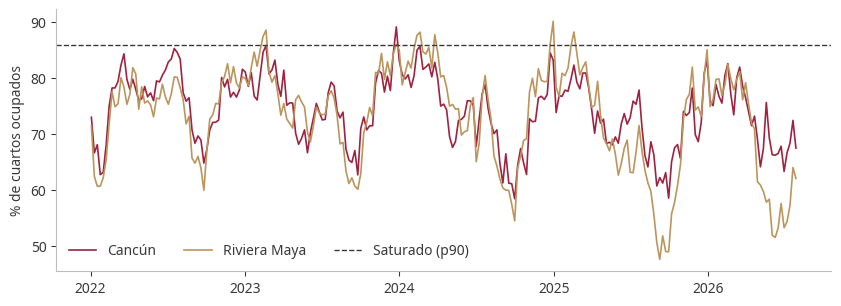

,cancun_estado,riviera_estado
concurrido,164,149
tranquilo,74,81
saturado,1,9


In [22]:
print(f"p50 = {s.corte_p50.iloc[0]:.2f} %, p90 = {s.corte_p90.iloc[0]:.2f} %")
fig, ax = plt.subplots(figsize=(10, 3.4))
ax.plot(s.semana, s.cancun_ocupacion_pct, color=GUINDA, lw=1.2, label="Cancún")
ax.plot(s.semana, s.riviera_ocupacion_pct, color=DORADO, lw=1.2, label="Riviera Maya")
ax.axhline(s.corte_p90.iloc[0], color=GRIS_TEXTO, ls="--", lw=1, label="Saturado (p90)")
ax.set_ylabel("% de cuartos ocupados"); ax.legend(frameon=False, ncol=3); plt.show()
s[["cancun_estado", "riviera_estado"]].apply(pd.Series.value_counts).fillna(0).astype(int)

### 2. Tormentas cerca
Regla de la Fase 5: un punto de HURDAT2 a ≤ 200 km de Chetumal con viento ≥ 34 nudos. **2026 aún no se publica**: esas
semanas quedan como *sin dato*, que no es lo mismo que "sin tormenta".

In [23]:
s.groupby(s.tormenta.map({True: "tormenta", False: "sin tormenta", None: "sin dato (2026)"}).fillna("sin dato (2026)")).size(), \
    s[s.tormenta == True][["semana", "tormenta_nombre"]]

(tormenta
 sin dato (2026)     30
 sin tormenta       206
 tormenta             3
 dtype: int64,
         semana tormenta_nombre
 43  2022-10-31            Lisa
 145 2024-10-14          Nadine
 149 2024-11-11            Sara)

### 3. Clima raro con Isolation Forest
$s(x)=2^{-E[h(x)]/c(n)}$, con $c(n)=2H(n-1)-2(n-1)/n$. Un bosque por punto y por año, entrenado con todas las semanas
anteriores (ventana creciente). Una semana es rara si su $s(x)$ pasa el percentil 95 de las semanas de entrenamiento.
El corte automático (`contamination="auto"`) se descartó porque marcaba 47 % de las semanas de Chetumal.

          sum  count      mean
punto                         
chetumal   21    247   0.08502
kohunlich  17    247  0.068826


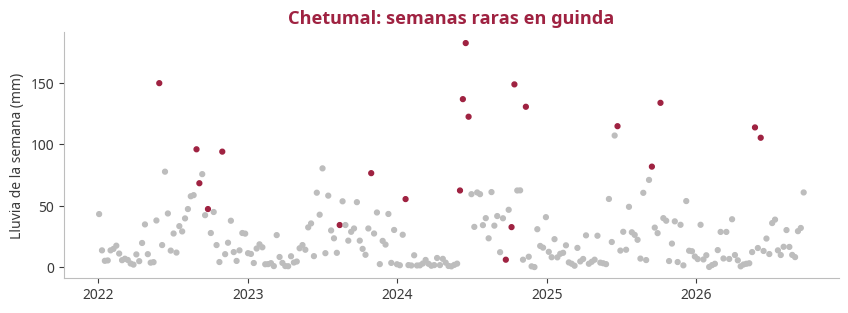

In [24]:
c = sn.anomalias_clima(sn.clima_semanal())
c = c[c.n_entrena > 0]
print(c.groupby("punto").clima_raro.agg(["sum", "count", "mean"]).round(3))
fig, ax = plt.subplots(figsize=(10, 3.2))
x = c[c.punto == "chetumal"]
ax.scatter(x.semana, x.lluvia_mm, c=x.clima_raro.map({True: GUINDA, False: "#BDBDBD"}), s=12)
ax.set_ylabel("Lluvia de la semana (mm)"); ax.set_title("Chetumal: semanas raras en guinda"); plt.show()

### 4. El motor de reglas, con un ejemplo
Sur: tormenta, clima raro en su punto o llegadas del mes anterior **por arriba** del rango del 90 % → pausa, y el dinero
pasa a la siguiente semana permitida. Norte: si Cancún o Riviera Maya están saturados → "¿Ibas al norte?" hacia el lugar
del sur encendido con más espacio libre.

In [25]:
ej = s[s.tormenta == True].iloc[0].to_dict()
plan = mt.plan_desde_gold(pd.read_parquet(GOLD / "presupuesto_plan.parquet"),
                          __import__("torre.campana.presupuesto", fromlist=["x"]).tabla_meses())
dec, nor = mt.decidir(ej, plan, mt.Memoria())
pd.DataFrame(dec)[["semana", "lugar", "accion", "motivo", "pesos_plan", "arrastre"]]

,semana,lugar,accion,motivo,pesos_plan,arrastre
0,2022-10-31,Chetumal,pausado,tormenta cerca (Lisa); clima raro (94 mm de lluvia en la...,826.59812,826.59812
1,2022-10-31,Bahía Calderitas–Oxtankah,pausado,tormenta cerca (Lisa); clima raro (94 mm de lluvia en la...,2655.25356,2655.25356
2,2022-10-31,Ruta arqueológica del sur,pausado,tormenta cerca (Lisa); clima raro (90 mm de lluvia en la...,3035.37524,3035.37524


### 5. La reproducción con Spark Structured Streaming
`python -m torre.envivo.torre` escribe una semana por archivo y Spark las lee con `maxFilesPerTrigger = 1`: cada lote es
una semana. Se comprueba que llegaron todas y en orden.

In [26]:
print(f"Lotes: {d.lote.nunique()} · semanas: {d.semana.nunique()} · en orden: {d.groupby('lote').semana.first().is_monotonic_increasing}")
print(f"Pesos gastados ${d.pesos_gastados.sum():,.0f} = planeados ${d.pesos_plan.sum():,.0f}")
display(d.pivot_table(index="lugar", columns="accion", values="semana", aggfunc="count", fill_value=0))
print(f"¿Ibas al norte?: {nt.ibas_al_norte.sum()} semanas →", nt[nt.ibas_al_norte].destino.value_counts().to_dict())

Lotes: 239 · semanas: 239 · en orden: True
Pesos gastados $876,901 = planeados $876,901


accion,encendido,fuera del plan,pausado,temporada alta
lugar,,,,
Bahía Calderitas–Oxtankah,106,57,14,62
Chetumal,145,57,19,18
Ruta arqueológica del sur,104,57,15,63


¿Ibas al norte?: 6 semanas → {'Bahía Calderitas–Oxtankah': 6}


### 6. Qué se concluye
1. **La Torre pausa poco y por razones claras:** 48 pausas de lugar-semana en 239 semanas, casi todas por clima raro. Las
   tres tormentas (Lisa 2022, Nadine y Sara 2024) pausaron los tres lugares.
2. **No se pierde dinero:** lo pausado se gasta en la siguiente semana permitida.
3. **El norte casi nunca se satura en lo semanal** (Cancún 1 semana, Riviera Maya 9): "¿Ibas al norte?" se encendió 6
   semanas. La señal útil del norte es la temporada (Fase 5), no la semana.
4. **Limitaciones:** el sur no tiene ningún dato semanal oficial; las tormentas de 2026 no se conocen; se supone que el
   dato mensual se conoce al empezar el mes siguiente; el plan de dinero es el de la Fase 6 aplicado a años pasados.